# Flight Delay Prediction — Exhaustive EDA
### Dataset : NYC Flights 2013  |  336,776 rows × 41 features  |  Binary classification

---

## 1. Business problem
Airlines and airports lose money every time a flight is delayed — crew reassignment, fuel burn, gate congestion, passenger compensation. A model that flags *which* flights are likely to be delayed before take-off lets operations teams re-route, re-staff, or pre-notify passengers.

**Target:** `is_delayed` — a flag that is `1` if the flight's arrival delay is more than **15 minutes** (the FAA's on-time threshold), and `0` otherwise.

**Data source** (real 2013 data for every flight departing JFK, LGA, and EWR, available in the `nycflights13` Python package):
- `flights` — 336,776 flight records × 19 columns
- `weather` — hourly weather at the origin airport × 15 columns
- `planes` — aircraft metadata × 9 columns
- `airlines` + `airports` — lookup tables

After joining on the natural keys we get **336,776 × 41** — a real, enterprise-scale EDA problem.

## 2. EDA scope
1. Data import & integration
2. Data characteristics (shape, dtypes, memory, cardinality)
3. Missing-data handling (drop vs impute)
4. Duplicate-data handling
5. Statistical analysis (descriptive + inferential)
6. Univariate / Bivariate / Multivariate analysis
7. Correlation + multicollinearity → feature drop with justification
8. Outlier detection (IQR + z-score) and handling (clipping)
9. Transformation (log) and scaling (StandardScaler)
10. Summary observations & insights for downstream modelling


## Section 1 — Environment setup

In [1]:
# Standard data-science stack (nothing exotic)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Two simple statistical tests we'll use later
from scipy.stats import ttest_ind, chi2_contingency

# One scaler from sklearn
from sklearn.preprocessing import StandardScaler

# Display settings
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Setup complete.')

Setup complete.


## Section 2 — Data import and integration

We pull the five raw tables from `nycflights13` and join them on their natural keys. Any one of these tables in isolation gives a narrow view of a flight — joined, they describe the flight plus the weather, plus the plane's hardware, plus the route geography.

In [ ]:
#pip install nycflights13

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.7 MB 326.8 kB/s eta 0:00:27
     ---------------------------------------- 0.0/8.7 MB 326.8 kB/s eta 0:00:27
     ---------------------------------------- 0.1/8.7 MB 403.5 kB/s eta 0:00:22
     ---------------------------------------- 0.1/8.7 MB 403.5 kB/s eta 0:00:22
     ---------------------------------------- 0.1/8.7 MB 403.5 kB/s eta 0:00:22
     ---------------------------------------- 0.1/8.7 MB 403.5 kB/s eta 0:00:22
     -----------

In [5]:
from nycflights13 import flights, weather, planes, airports, airlines

# Raw table sizes
print('--- Raw table shapes ---')
for name, tbl in [('flights', flights), ('weather', weather),
                  ('planes', planes), ('airports', airports), ('airlines', airlines)]:
    print(f'{name:10s} {tbl.shape}')

--- Raw table shapes ---
flights    (336776, 19)
weather    (26115, 15)
planes     (3322, 9)
airports   (1458, 8)
airlines   (16, 2)


### 2.1 Join strategy
- `flights` ⟵ LEFT JOIN `weather` on (`origin`, `time_hour`) → hourly weather at the origin
- `flights` ⟵ LEFT JOIN `planes` on `tailnum` → aircraft metadata (manufacturer, engines, seats, age)
- `flights` ⟵ LEFT JOIN `airlines` on `carrier` → readable carrier name
- `flights` ⟵ LEFT JOIN `airports` on `dest` → destination lat/lon/altitude

LEFT joins preserve every flight record; any unmatched rows will surface as NaN and we'll handle them in the missing-data section.

In [6]:
# Rename columns to avoid collisions when we merge
planes_r  = planes.rename(columns={'year':'plane_year','type':'plane_type','speed':'plane_speed'})
weather_r = weather.drop(columns=['year','month','day','hour'])  # keep time_hour as the only join key
airports_r = airports[['faa','name','lat','lon','alt']].rename(
    columns={'faa':'dest','name':'dest_name','lat':'dest_lat','lon':'dest_lon','alt':'dest_alt'})
airlines_r = airlines.rename(columns={'name':'carrier_name'})

# Merge step by step — each merge adds more columns
df = (flights
      .merge(weather_r,  on=['origin','time_hour'], how='left')
      .merge(planes_r,   on='tailnum',               how='left')
      .merge(airlines_r, on='carrier',               how='left')
      .merge(airports_r, on='dest',                  how='left'))

print('Merged shape:', df.shape)
df.head(3)

Merged shape: (336776, 41)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,plane_year,plane_type,manufacturer,model,engines,seats,plane_speed,engine,carrier_name,dest_name,dest_lat,dest_lon,dest_alt
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,1999.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,NaN,Turbo-fan,United Air Lines Inc.,George Bush Intercontinental,29.984433,-95.341442,97.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0,1998.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,NaN,Turbo-fan,United Air Lines Inc.,George Bush Intercontinental,29.984433,-95.341442,97.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,1990.0,Fixed wing multi engine,BOEING,757-223,2.0,178.0,NaN,Turbo-fan,American Airlines Inc.,Miami Intl,25.793250,-80.290556,8.0


## Section 3 — Data characteristics

Before any cleaning decisions we want to understand what we have: how big is the dataset, what types do the columns hold, how much memory do they use, and how many distinct values does each column have.

In [7]:
print('Rows   :', df.shape[0])
print('Columns:', df.shape[1])
print('Memory :', f'{df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Rows   : 336776
Columns: 41
Memory : 325.3 MB


In [8]:
# .info() gives a quick summary of each column and its non-null count
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 41 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute    

In [9]:
# Count columns by data type
dtype_counts = df.dtypes.value_counts()
print('Data-type breakdown:')
print(dtype_counts)

Data-type breakdown:
float64    21
object     11
int64       9
Name: count, dtype: int64


In [10]:
# Split columns into numeric vs categorical — we'll treat them differently in later steps
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numeric columns    ({len(num_cols)}):', num_cols)
print(f'Categorical columns({len(cat_cols)}):', cat_cols)

Numeric columns    (30): ['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'arr_delay', 'flight', 'air_time', 'distance', 'hour', 'minute', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib', 'plane_year', 'engines', 'seats', 'plane_speed', 'dest_lat', 'dest_lon', 'dest_alt']
Categorical columns(11): ['carrier', 'tailnum', 'origin', 'dest', 'time_hour', 'plane_type', 'manufacturer', 'model', 'engine', 'carrier_name', 'dest_name']


In [11]:
# Unique values per column (cardinality)
# Columns with 100% unique values are row IDs — no modelling signal
# Columns with only 1 unique value are constants — also useless
card = df.nunique().sort_values(ascending=False).to_frame('n_unique')
card['pct_unique'] = (card['n_unique'] / len(df) * 100).round(2)
card

,n_unique,pct_unique
time_hour,6936,2.06
tailnum,4043,1.20
flight,3844,1.14
humid,2442,0.73
arr_time,1411,0.42
dep_time,1318,0.39
sched_arr_time,1163,0.35
sched_dep_time,1021,0.30
arr_delay,577,0.17
dep_delay,527,0.16


**Reading the cardinality table:** columns with 100 % unique values (like `flight` or `tailnum`) are row identifiers and carry no generalisable signal. Columns with a single unique value (`year` = 1) are constants and should be dropped. These are first-pass clean-up candidates.

In [14]:
# Descriptive statistics for numeric columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year,336776.0,2013.000000,0.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000
month,336776.0,6.548510,3.414457,1.000000,4.000000,7.000000,10.000000,12.000000
day,336776.0,15.710787,8.768607,1.000000,8.000000,16.000000,23.000000,31.000000
dep_time,328521.0,1349.109947,488.281791,1.000000,907.000000,1401.000000,1744.000000,2400.000000
sched_dep_time,336776.0,1344.254840,467.335756,106.000000,906.000000,1359.000000,1729.000000,2359.000000
dep_delay,328521.0,12.639070,40.210061,-43.000000,-5.000000,-2.000000,11.000000,1301.000000
arr_time,328063.0,1502.054999,533.264132,1.000000,1104.000000,1535.000000,1940.000000,2400.000000
sched_arr_time,336776.0,1536.380220,497.457142,1.000000,1124.000000,1556.000000,1945.000000,2359.000000
arr_delay,327346.0,6.895377,44.633292,-86.000000,-17.000000,-5.000000,14.000000,1272.000000
flight,336776.0,1971.923620,1632.471938,1.000000,553.000000,1496.000000,3465.000000,8500.000000


In [15]:
# Descriptive statistics for categorical columns
df[cat_cols].describe().T

,count,unique,top,freq
carrier,336776,16,UA,58665
tailnum,334264,4043,N725MQ,575
origin,336776,3,EWR,120835
dest,336776,105,ORD,17283
time_hour,336776,6936,2013-09-13T12:00:00Z,94
plane_type,284170,3,Fixed wing multi engine,282074
manufacturer,284170,35,BOEING,82912
model,284170,127,A320-232,45831
engine,284170,6,Turbo-fan,240915
carrier_name,336776,16,United Air Lines Inc.,58665


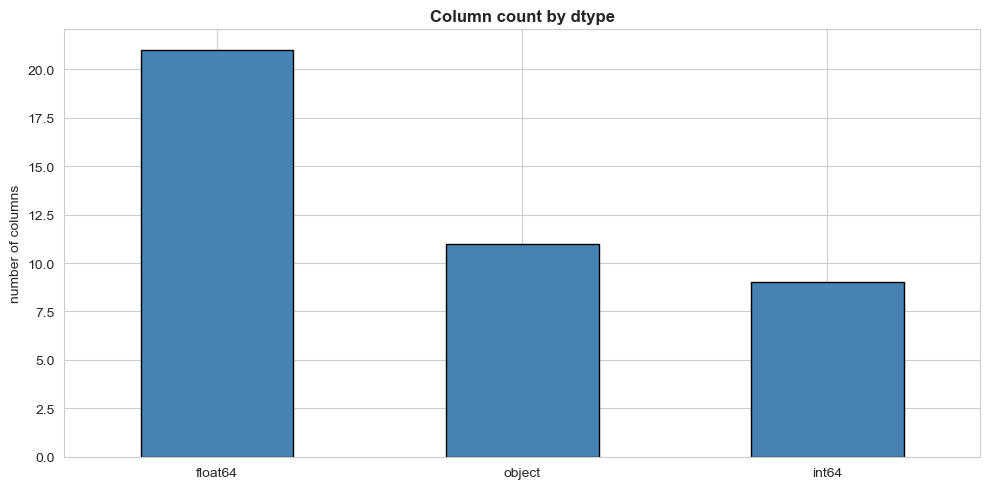

In [16]:
# Bar chart of the dtype split
dtype_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Column count by dtype')
plt.ylabel('number of columns'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Section 4 — Missing-data handling

We ask three questions before deciding what to do:
1. **How much is missing?** — less than 5 % we impute, 5–40 % we investigate, more than 40 % we usually drop the column.
2. **Is the missingness structured?** — do certain columns go NaN together (e.g. all the aircraft-metadata columns when the tail number isn't in the `planes` table)?
3. **Is the missingness informative?** — sometimes a NaN itself is a signal (e.g. `dep_time` is NaN only when the flight was cancelled).

In [17]:
# Count missing values per column (only show columns with at least one NaN)
missing = pd.DataFrame({
    'n_missing':   df.isna().sum(),
    'pct_missing': (df.isna().mean()*100).round(2)
})
missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)
missing

,n_missing,pct_missing
plane_speed,335813,99.71
wind_gust,256391,76.13
plane_year,57912,17.20
engine,52606,15.62
seats,52606,15.62
engines,52606,15.62
model,52606,15.62
manufacturer,52606,15.62
plane_type,52606,15.62
pressure,38788,11.52


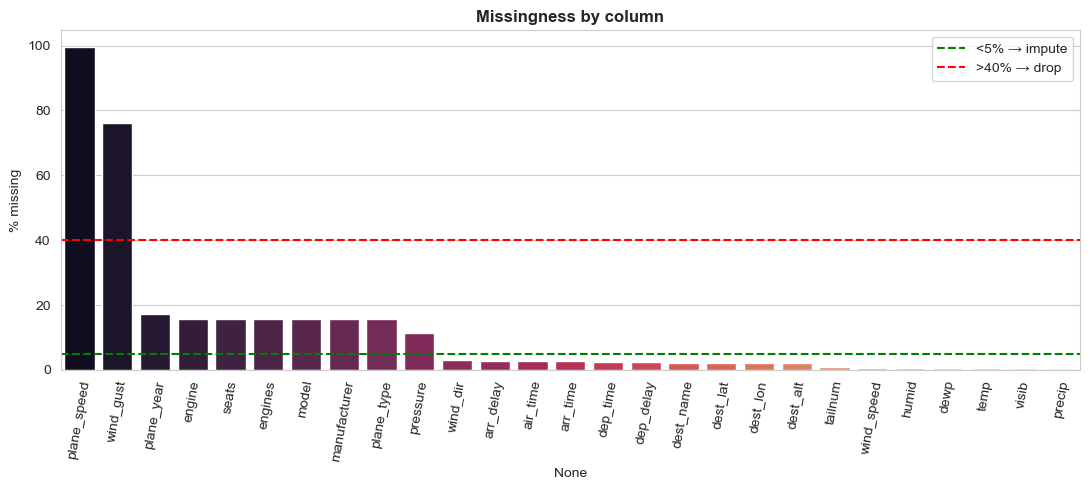

In [18]:
# Bar chart of missing percentages with guideline thresholds
plt.figure(figsize=(11,5))
sns.barplot(x=missing.index, y=missing['pct_missing'], palette='rocket')
plt.xticks(rotation=80)
plt.ylabel('% missing'); plt.title('Missingness by column')
plt.axhline(5,  ls='--', c='green', label='<5% → impute')
plt.axhline(40, ls='--', c='red',   label='>40% → drop')
plt.legend(); plt.tight_layout(); plt.show()

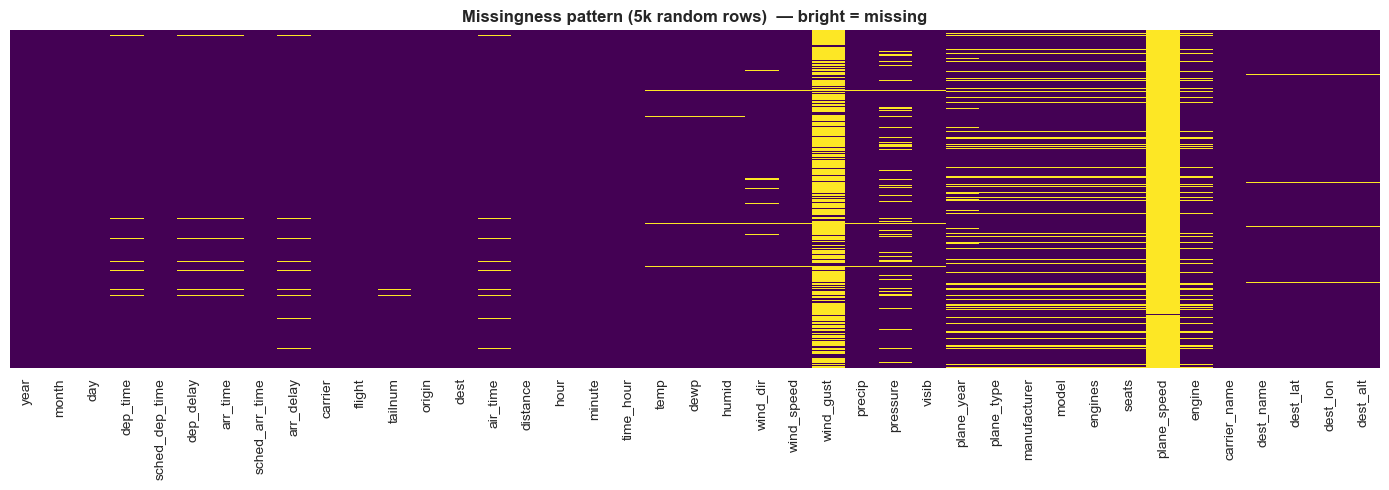

In [19]:
# Missingness heatmap — pandas .isna() gives a boolean DataFrame, plot a sample of it
# Bright spots = missing values. Vertical bands show columns that go NaN together.
sample = df.sample(5000, random_state=RANDOM_SEED).reset_index(drop=True)
plt.figure(figsize=(14, 5))
sns.heatmap(sample.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missingness pattern (5k random rows)  — bright = missing')
plt.tight_layout(); plt.show()

### 4.1 Drop/impute decisions

| Column | % missing | Decision | Reason |
|---|---|---|---|
| `plane_speed` | ~99.7 % | **drop** | too sparse to save |
| `wind_gust` | ~76 % | **drop** | we already have `wind_speed` |
| `pressure` | ~11.5 % | **impute (median)** | borderline; weather is stable enough that median works |
| `plane_year`, `engines`, `seats`, aircraft columns | ~17 % | **impute (median / mode)** | missing because tail number isn't in the planes table |
| `dep_time`, `arr_time`, `air_time`, `arr_delay` | ~2.5 % | **drop rows** | these are cancelled flights — no arrival means no target |
| `temp`, `dewp`, `humid`, `visib`, `precip`, `wind_speed`, `wind_dir` | < 3 % | **impute (median)** | tiny gap, no effect on the analysis |
| `tailnum` | 0.7 % | **drop rows** | rare; can't recover aircraft ID |
| destination-side (`dest_*`) | 2.3 % | **drop rows** | a few flights to airports missing from the lookup |

In [20]:
# Apply the decisions from the table above
DROP_COLS     = ['plane_speed', 'wind_gust']
DROP_NA_ROWS  = ['dep_time', 'arr_time', 'air_time', 'arr_delay', 'tailnum', 'dest_lat']
IMPUTE_MEDIAN = ['pressure', 'plane_year', 'engines', 'seats',
                 'temp', 'dewp', 'humid', 'visib', 'precip',
                 'wind_speed', 'wind_dir']
IMPUTE_MODE   = ['plane_type', 'manufacturer', 'model', 'engine']

df_clean = df.drop(columns=DROP_COLS)
df_clean = df_clean.dropna(subset=DROP_NA_ROWS)

# Median imputation for numeric columns
for c in IMPUTE_MEDIAN:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Mode imputation for categorical columns (mode = most common value)
for c in IMPUTE_MODE:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])

print(f'Before : {df.shape}')
print(f'After  : {df_clean.shape}')
print(f'Rows dropped : {len(df) - len(df_clean):,}  ({(len(df)-len(df_clean))/len(df)*100:.2f} %)')
print(f'Remaining NaN: {df_clean.isna().sum().sum()}')

Before : (336776, 41)
After  : (319809, 39)
Rows dropped : 16,967  (5.04 %)
Remaining NaN: 0


In [21]:
# Safety check — zero NaNs should remain
assert df_clean.isna().sum().sum() == 0
print(' Dataset has zero missing values after handling.')

 Dataset has zero missing values after handling.


## Section 5 — Duplicate handling

A true duplicate would be two flight records with identical values in every column, including `time_hour`, `flight`, and `tailnum`. That's unlikely in real operations data, but we verify. We also check for *logical duplicates* (same flight number at the same scheduled time with the same plane) which would indicate a data-pipeline bug.

In [22]:
print('Exact duplicates  :', df_clean.duplicated().sum())
print('Logical duplicates:', df_clean.duplicated(subset=['flight','time_hour','tailnum']).sum())

Exact duplicates  : 0
Logical duplicates: 0


In [23]:
# Remove any duplicates found
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Removed {before - len(df_clean)} duplicate rows. New shape: {df_clean.shape}')

Removed 0 duplicate rows. New shape: (319809, 39)


## Section 6 — Target variable engineering

The FAA defines a flight as "on-time" if it arrives within 15 minutes of its scheduled arrival. We mirror that convention.

**⚠️ Data leakage check** — `arr_delay` is the *source* of the target (`is_delayed = arr_delay > 15`). If we kept it as a predictor we'd get a trivially perfect model with zero learning signal — so we drop it explicitly below. `dep_delay`, `dep_time`, `arr_time`, `air_time` are all recorded *after* or *during* the flight. For a real pre-flight prediction model these would also leak the answer; because this notebook is EDA-focused (not production modelling), we keep them for analysis but flag them in the final summary.

In [24]:
# Create the binary target
df_clean['is_delayed'] = (df_clean['arr_delay'] > 15).astype(int)
print('Class distribution:')
print(df_clean['is_delayed'].value_counts())
print()
print('Class proportions:')
print(df_clean['is_delayed'].value_counts(normalize=True).round(4))

Class distribution:
is_delayed
0    243748
1     76061
Name: count, dtype: int64

Class proportions:
is_delayed
0    0.7622
1    0.2378
Name: proportion, dtype: float64


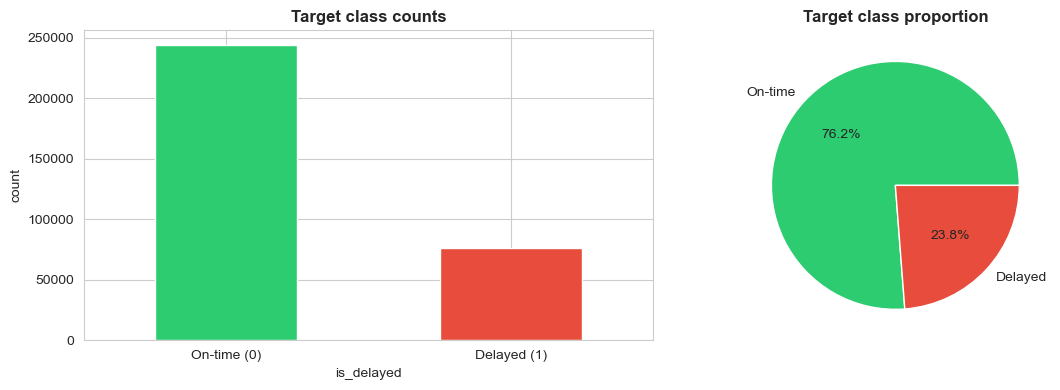

In [25]:
# Visualise target balance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_clean['is_delayed'].value_counts().plot(
    kind='bar', ax=ax[0], color=['#2ecc71','#e74c3c'])
ax[0].set_xticklabels(['On-time (0)','Delayed (1)'], rotation=0)
ax[0].set_title('Target class counts'); ax[0].set_ylabel('count')

df_clean['is_delayed'].value_counts(normalize=True).plot(
    kind='pie', ax=ax[1], autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    labels=['On-time','Delayed'])
ax[1].set_ylabel(''); ax[1].set_title('Target class proportion')
plt.tight_layout(); plt.show()

**Observation:** ~20 % of flights are delayed more than 15 minutes. This is moderate imbalance, not severe. For modelling we'd use `class_weight='balanced'`; for EDA the imbalance isn't extreme enough to distort group statistics.

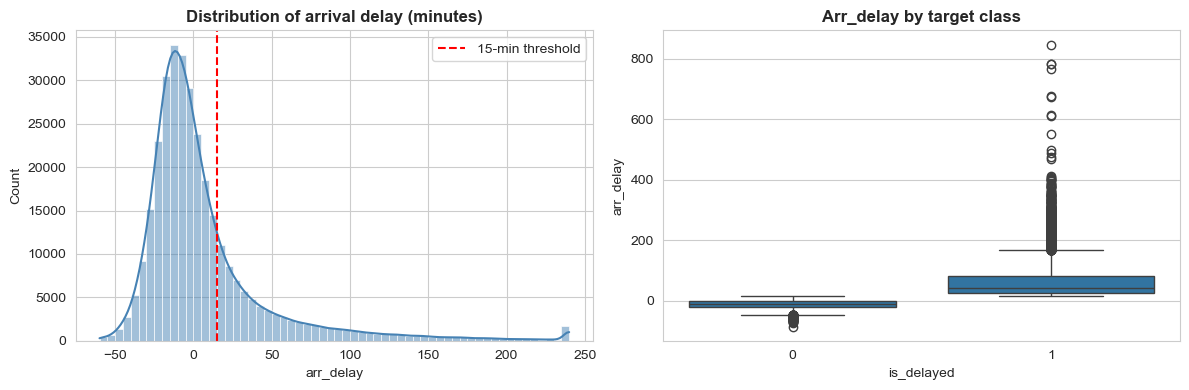

In [26]:
# Raw arrival-delay distribution (the continuous form of the target)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
# Clip the tails just for plotting so extreme values don't squash the histogram
sns.histplot(df_clean['arr_delay'].clip(-60, 240), bins=60, kde=True, color='steelblue')
plt.axvline(15, ls='--', c='red', label='15-min threshold')
plt.title('Distribution of arrival delay (minutes)')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x='is_delayed', y='arr_delay', data=df_clean.sample(50000, random_state=RANDOM_SEED))
plt.title('Arr_delay by target class')
plt.tight_layout(); plt.show()

In [27]:
# Drop constants, IDs, and arr_delay (the source of the target)
print('Unique values in `year` column:', df_clean['year'].unique())
DROP_ID_CONST_LEAK = ['year', 'flight', 'tailnum', 'time_hour', 'dest_name', 'arr_delay']
df_clean = df_clean.drop(columns=[c for c in DROP_ID_CONST_LEAK if c in df_clean.columns])
print('Shape after dropping constants / IDs / target-source:', df_clean.shape)

Unique values in `year` column: [2013]
Shape after dropping constants / IDs / target-source: (319809, 34)


## Section 7 — Univariate analysis

We look at each column in isolation before moving on to relationships. For numeric columns we look at distribution shape, central tendency, spread, and skewness. For categorical columns we look at counts and concentration.

In [28]:
# Refresh the numeric/categorical lists after cleaning
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# Predictor lists exclude the target
predictors_num = [c for c in num_cols if c != 'is_delayed']
print(f'Numeric predictors: {len(predictors_num)}')
print(f'Categorical predictors: {len(cat_cols)}')

Numeric predictors: 25
Categorical predictors: 8


### 7.1 Numerical — histograms (distribution shape)

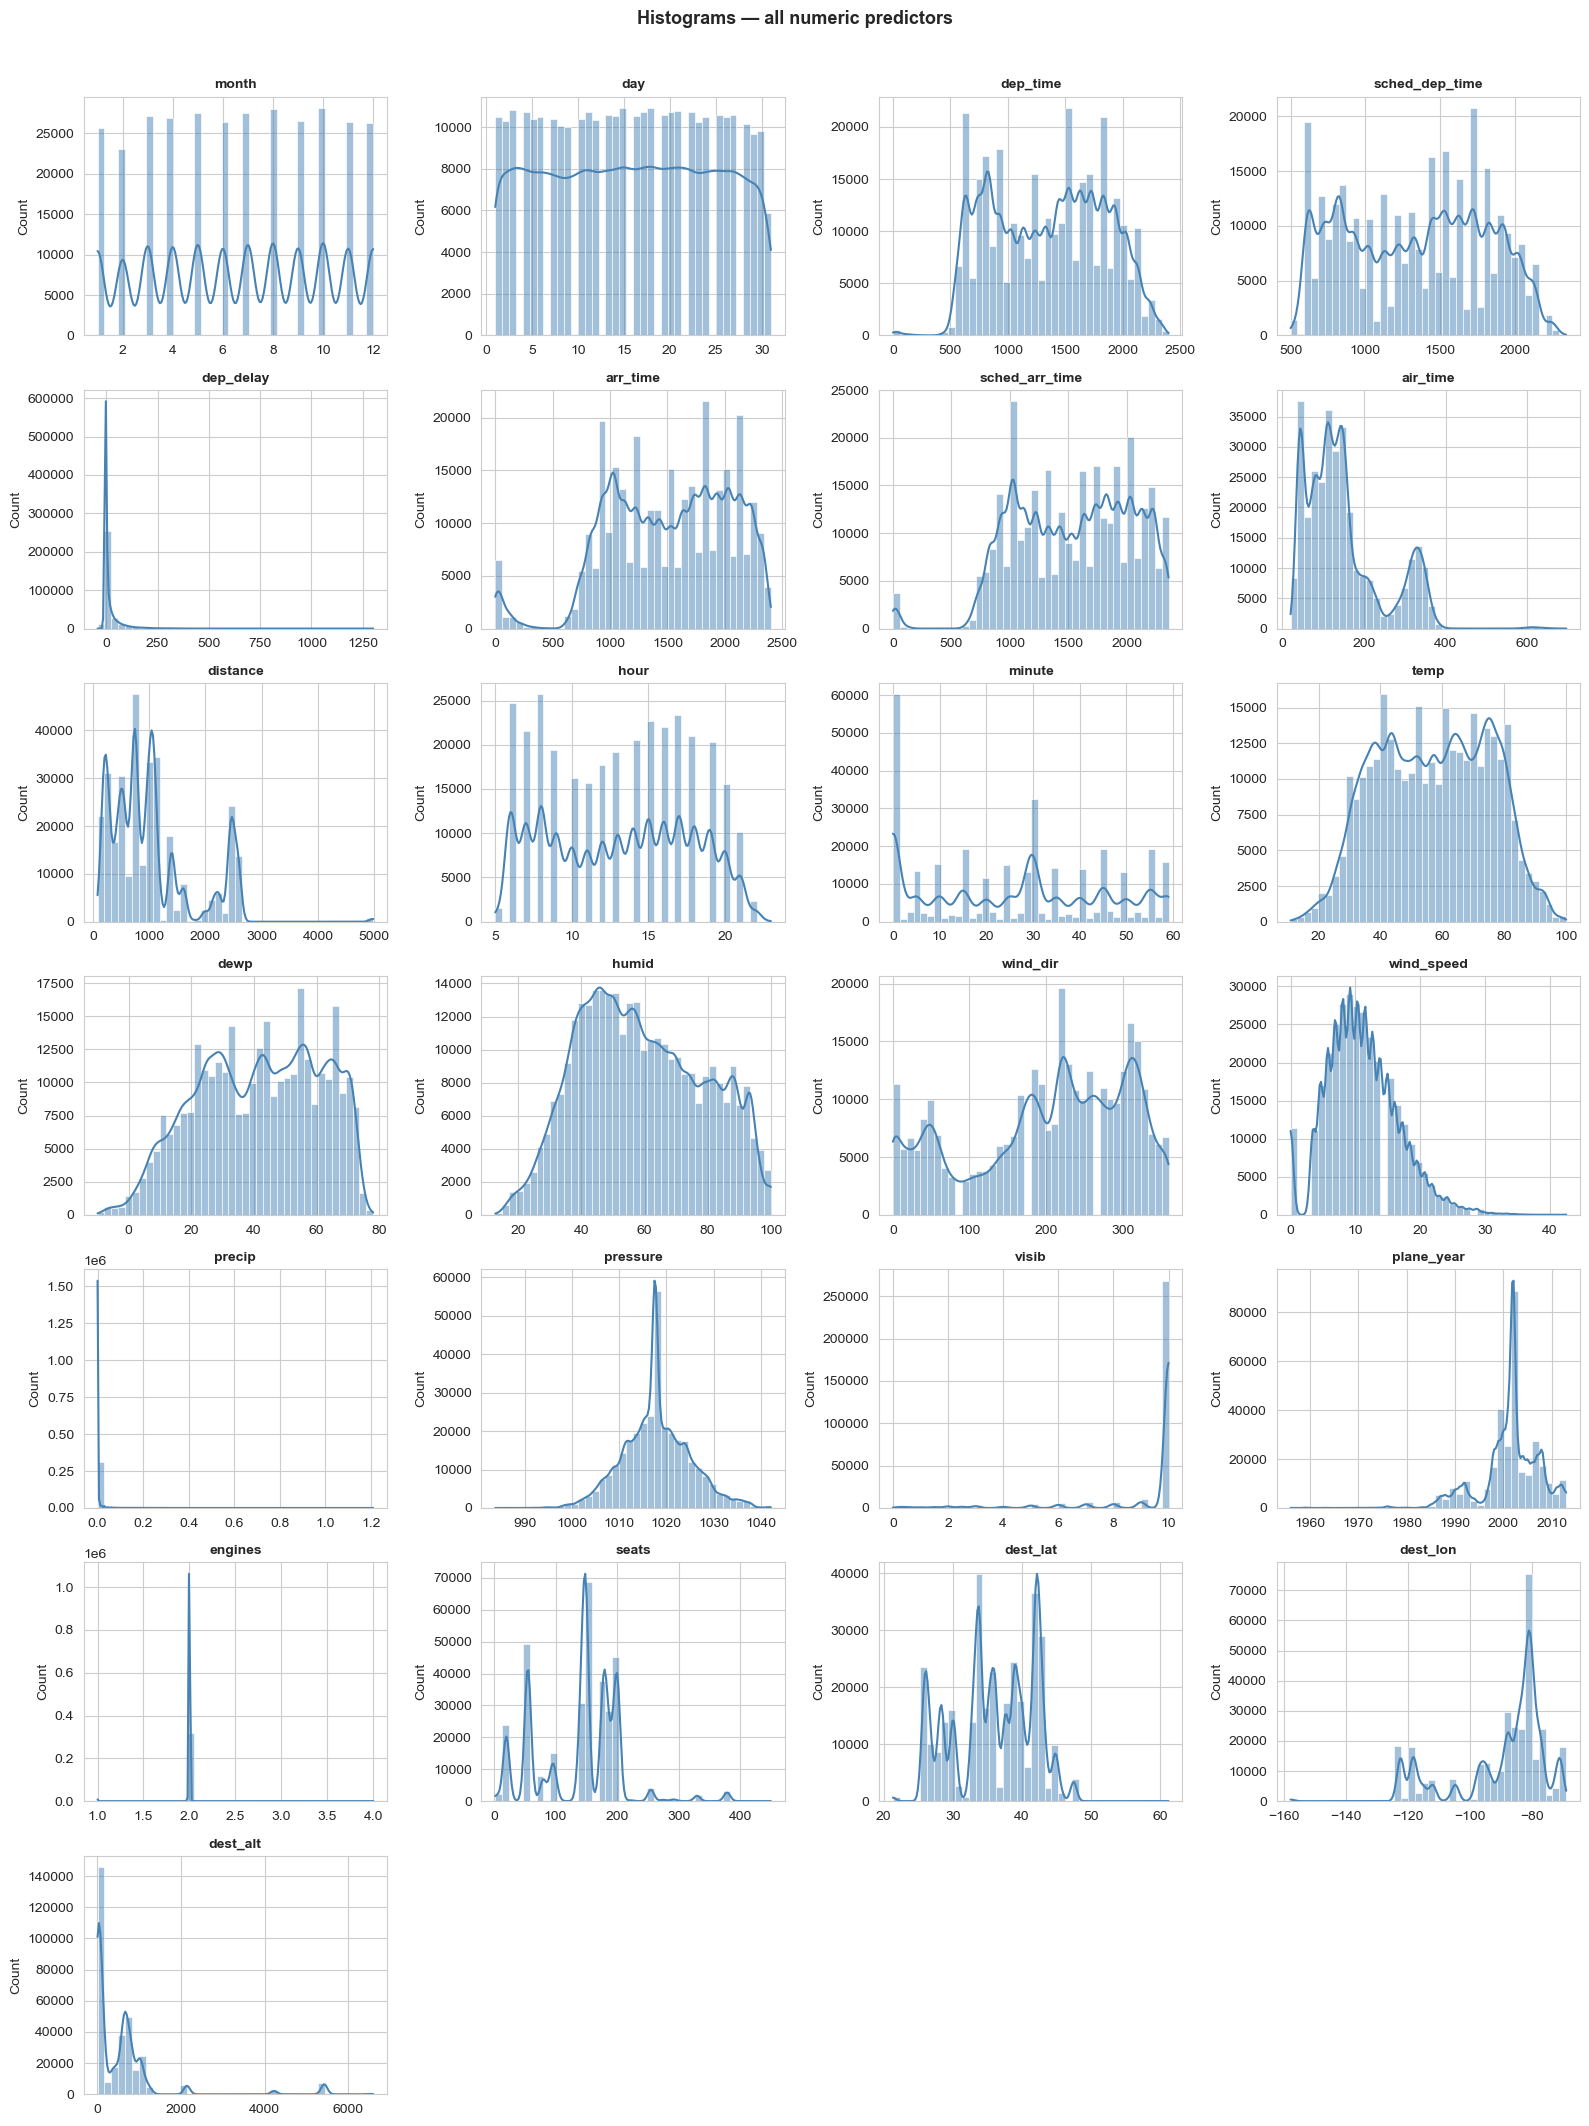

In [29]:
# Grid of histograms for every numeric predictor
n = len(predictors_num)
ncols, nrows = 4, int(np.ceil(n/4))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Histograms — all numeric predictors', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.2 Numerical — boxplots (spread + outlier preview)

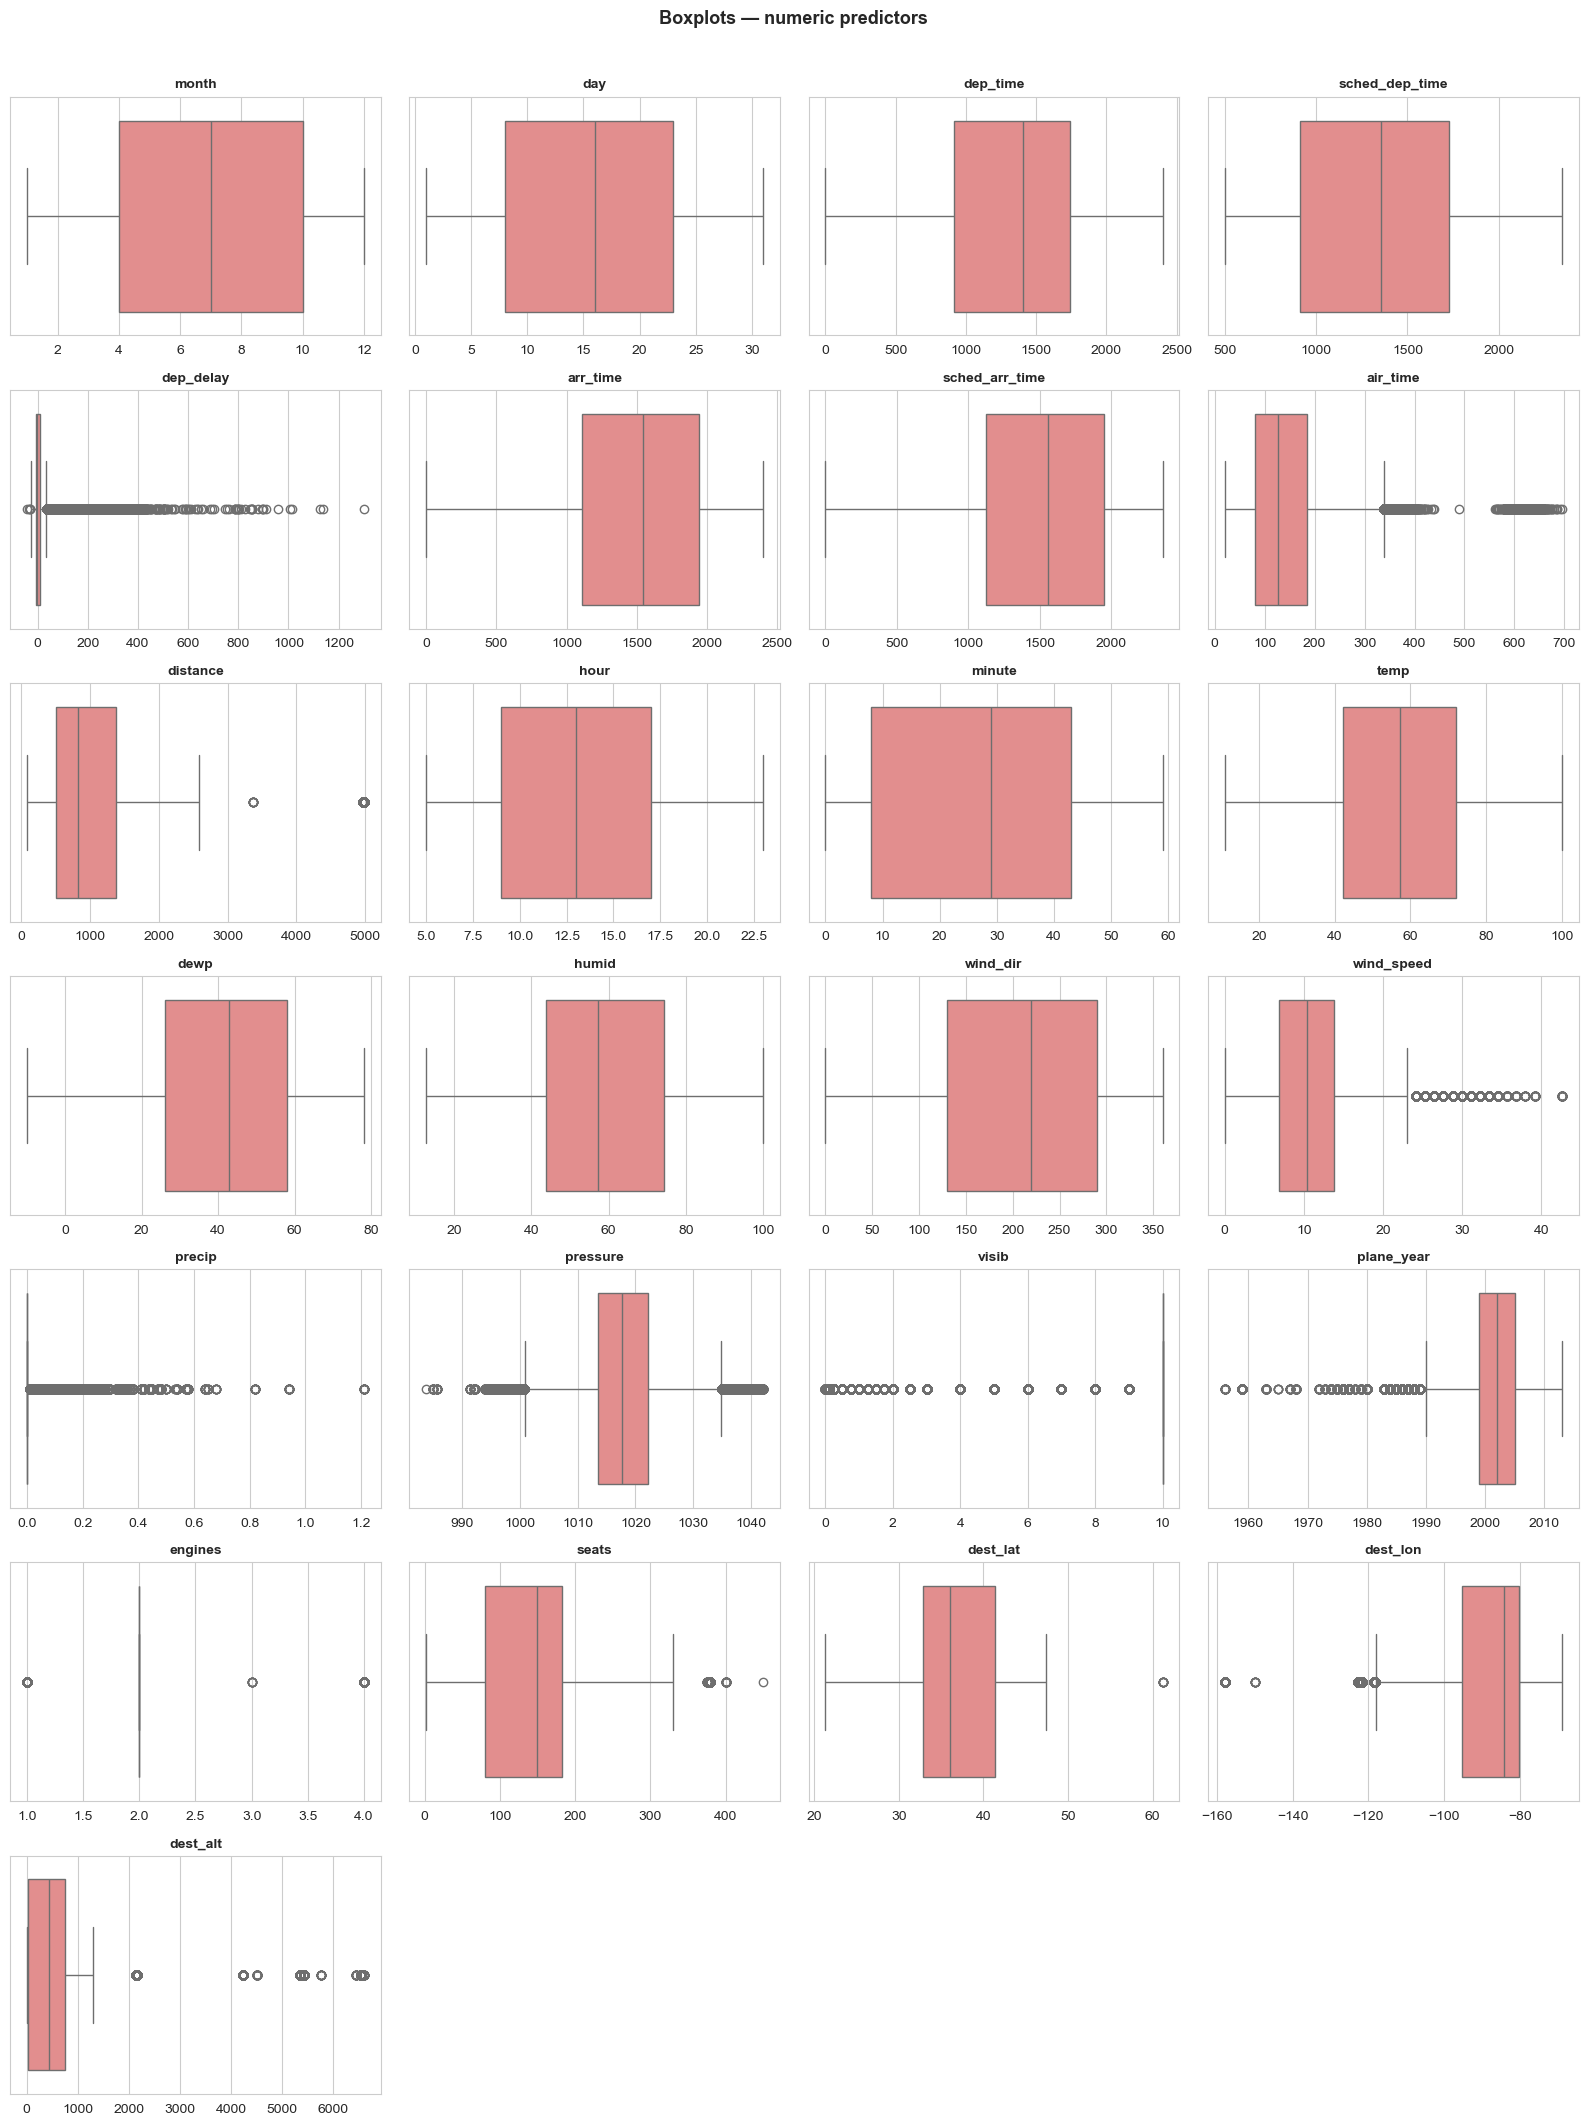

In [30]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.boxplot(x=df_clean[col], ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Boxplots — numeric predictors', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.3 Skewness table

In [26]:
# pandas has built-in .skew() and .kurt() methods — no extra imports needed
shape_stats = pd.DataFrame({
    'mean':     df_clean[predictors_num].mean(),
    'median':   df_clean[predictors_num].median(),
    'std':      df_clean[predictors_num].std(),
    'skew':     df_clean[predictors_num].skew(),
    'kurtosis': df_clean[predictors_num].kurt(),
}).round(3)
# Flag severity in plain words
shape_stats['skew_severity'] = pd.cut(
    shape_stats['skew'].abs(),
    bins=[-0.01, 0.5, 1.0, np.inf],
    labels=['low (|skew|<0.5)', 'moderate (0.5–1.0)', 'high (>1.0)'])
shape_stats.sort_values('skew', key=abs, ascending=False)

,mean,median,std,skew,kurtosis,skew_severity
precip,0.004,0.000,0.030,15.011,351.704,high (>1.0)
dep_delay,12.621,-2.000,40.264,4.817,44.316,high (>1.0)
dest_alt,583.758,433.000,943.989,3.800,16.274,high (>1.0)
engines,1.995,2.000,0.086,-3.607,221.575,high (>1.0)
visib,9.296,10.000,1.970,-3.082,8.780,high (>1.0)
dest_lon,-89.606,-83.994,15.047,-1.217,0.674,high (>1.0)
distance,1035.369,828.000,739.580,1.166,1.236,high (>1.0)
air_time,149.562,127.000,94.482,1.101,0.872,high (>1.0)
plane_year,2001.458,2002.000,5.881,-0.985,2.811,moderate (0.5–1.0)
wind_speed,11.059,10.357,5.515,0.579,0.764,moderate (0.5–1.0)


**Rule of thumb:** |skew| < 0.5 = approximately symmetric, 0.5–1.0 = moderately skewed, > 1.0 = highly skewed. Highly skewed features are candidates for transformation in Section 13.

### 7.4 Categorical — value counts

In [27]:
# Top-10 values for each categorical column
for c in cat_cols:
    print(f'\n--- {c} ({df_clean[c].nunique()} unique) ---')
    print(df_clean[c].value_counts().head(10))


--- carrier (16 unique) ---
carrier
UA    56614
EV    51108
B6    50389
DL    46335
AA    30561
MQ    25037
US    19831
9E    17294
WN    12044
VX     5116
Name: count, dtype: int64

--- origin (3 unique) ---
origin
EWR    115581
JFK    103088
LGA    101140
Name: count, dtype: int64

--- dest (100 unique) ---
dest
ATL    16837
ORD    16566
LAX    16026
BOS    15022
MCO    13967
CLT    13674
SFO    13173
FLL    11897
MIA    11593
DCA     9111
Name: count, dtype: int64

--- plane_type (3 unique) ---
plane_type
Fixed wing multi engine     317885
Fixed wing single engine      1547
Rotorcraft                     377
Name: count, dtype: int64

--- manufacturer (35 unique) ---
manufacturer
BOEING                           126666
EMBRAER                           63440
AIRBUS                            43951
AIRBUS INDUSTRIE                  40177
BOMBARDIER INC                    27430
MCDONNELL DOUGLAS AIRCRAFT CO      8840
MCDONNELL DOUGLAS                  3839
CANADAIR                   


--- carrier_name (16 unique) ---
carrier_name
United Air Lines Inc.       56614
ExpressJet Airlines Inc.    51108
JetBlue Airways             50389
Delta Air Lines Inc.        46335
American Airlines Inc.      30561
Envoy Air                   25037
US Airways Inc.             19831
Endeavor Air Inc.           17294
Southwest Airlines Co.      12044
Virgin America               5116
Name: count, dtype: int64


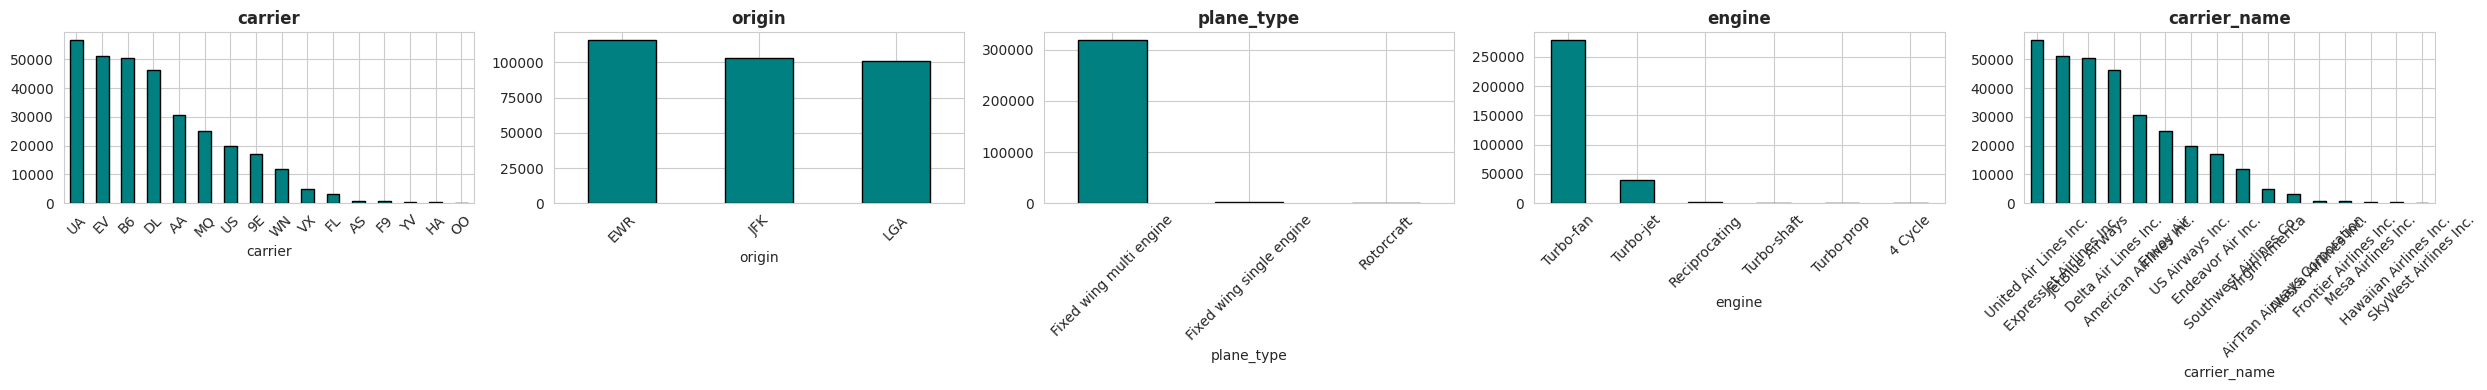

In [28]:
# Count plots for low-cardinality categorical columns
low_card_cats = [c for c in cat_cols if df_clean[c].nunique() <= 20]
if low_card_cats:
    fig, axes = plt.subplots(1, len(low_card_cats), figsize=(5*len(low_card_cats), 4))
    if len(low_card_cats) == 1: axes = [axes]
    for ax, c in zip(axes, low_card_cats):
        df_clean[c].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black')
        ax.set_title(c); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

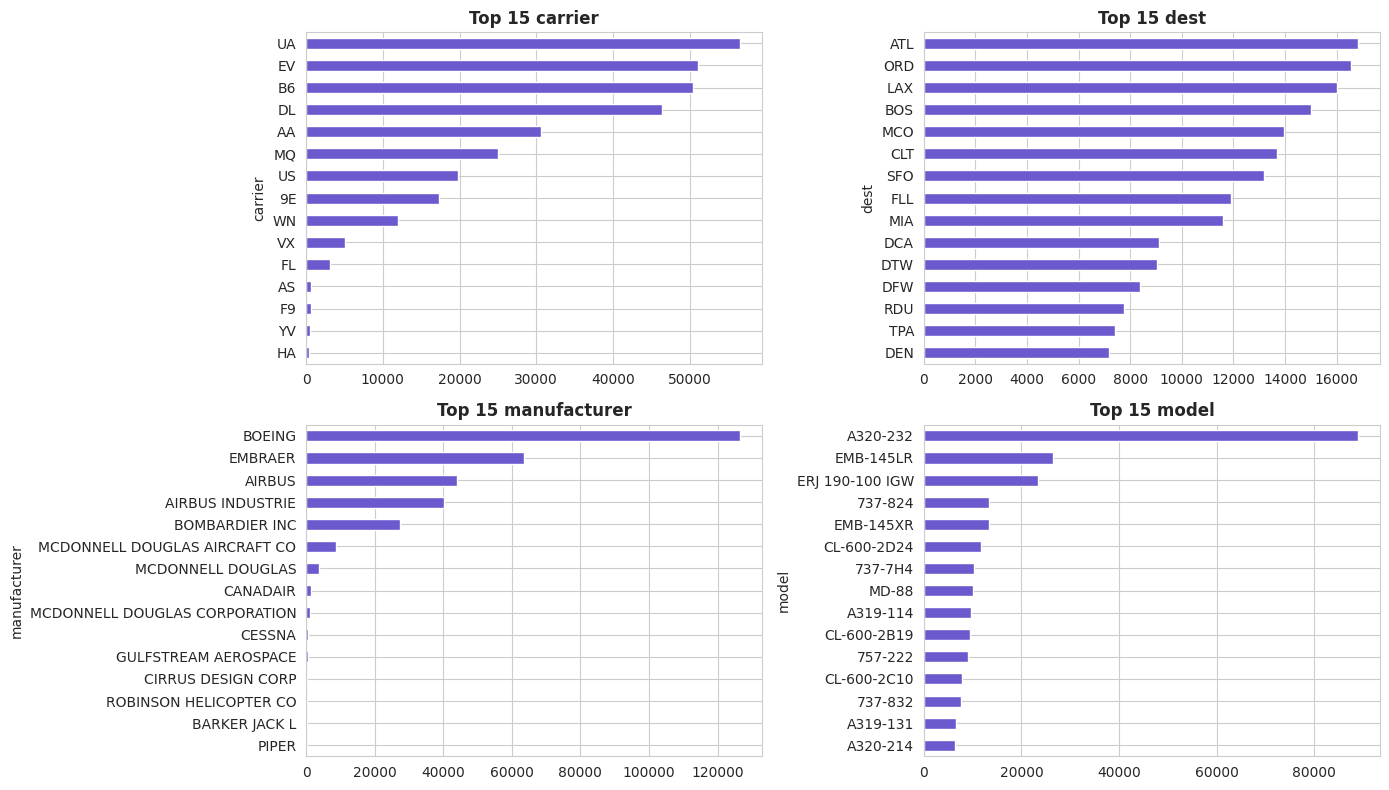

In [29]:
# Top 15 levels for high-cardinality categoricals (carrier, dest, manufacturer, model)
high_card = ['carrier', 'dest', 'manufacturer', 'model']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, c in zip(axes.flat, high_card):
    df_clean[c].value_counts().head(15).plot(kind='barh', ax=ax, color='slateblue')
    ax.set_title(f'Top 15 {c}'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 7.5 Time-based distributions

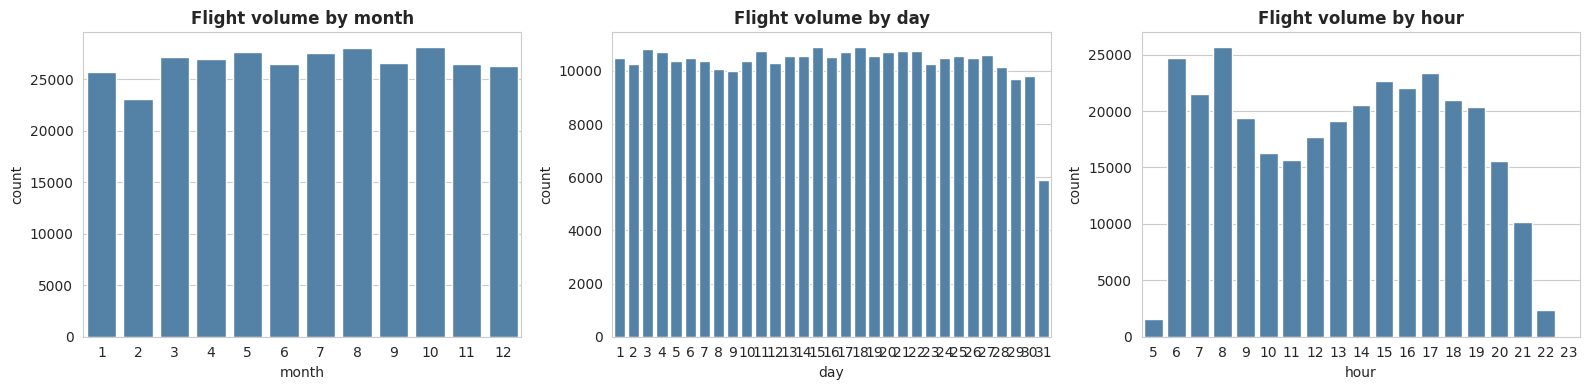

In [30]:
# How flight volume varies by month, day-of-month, hour-of-day
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ['month','day','hour']):
    sns.countplot(x=c, data=df_clean, ax=ax, color='steelblue')
    ax.set_title(f'Flight volume by {c}')
plt.tight_layout(); plt.show()

## Section 8 — Bivariate analysis

Each predictor is now paired with the target. This tells us whether — and in which direction — a feature discriminates between on-time and delayed flights.

### 8.1 Numeric predictor vs target — boxplot grid

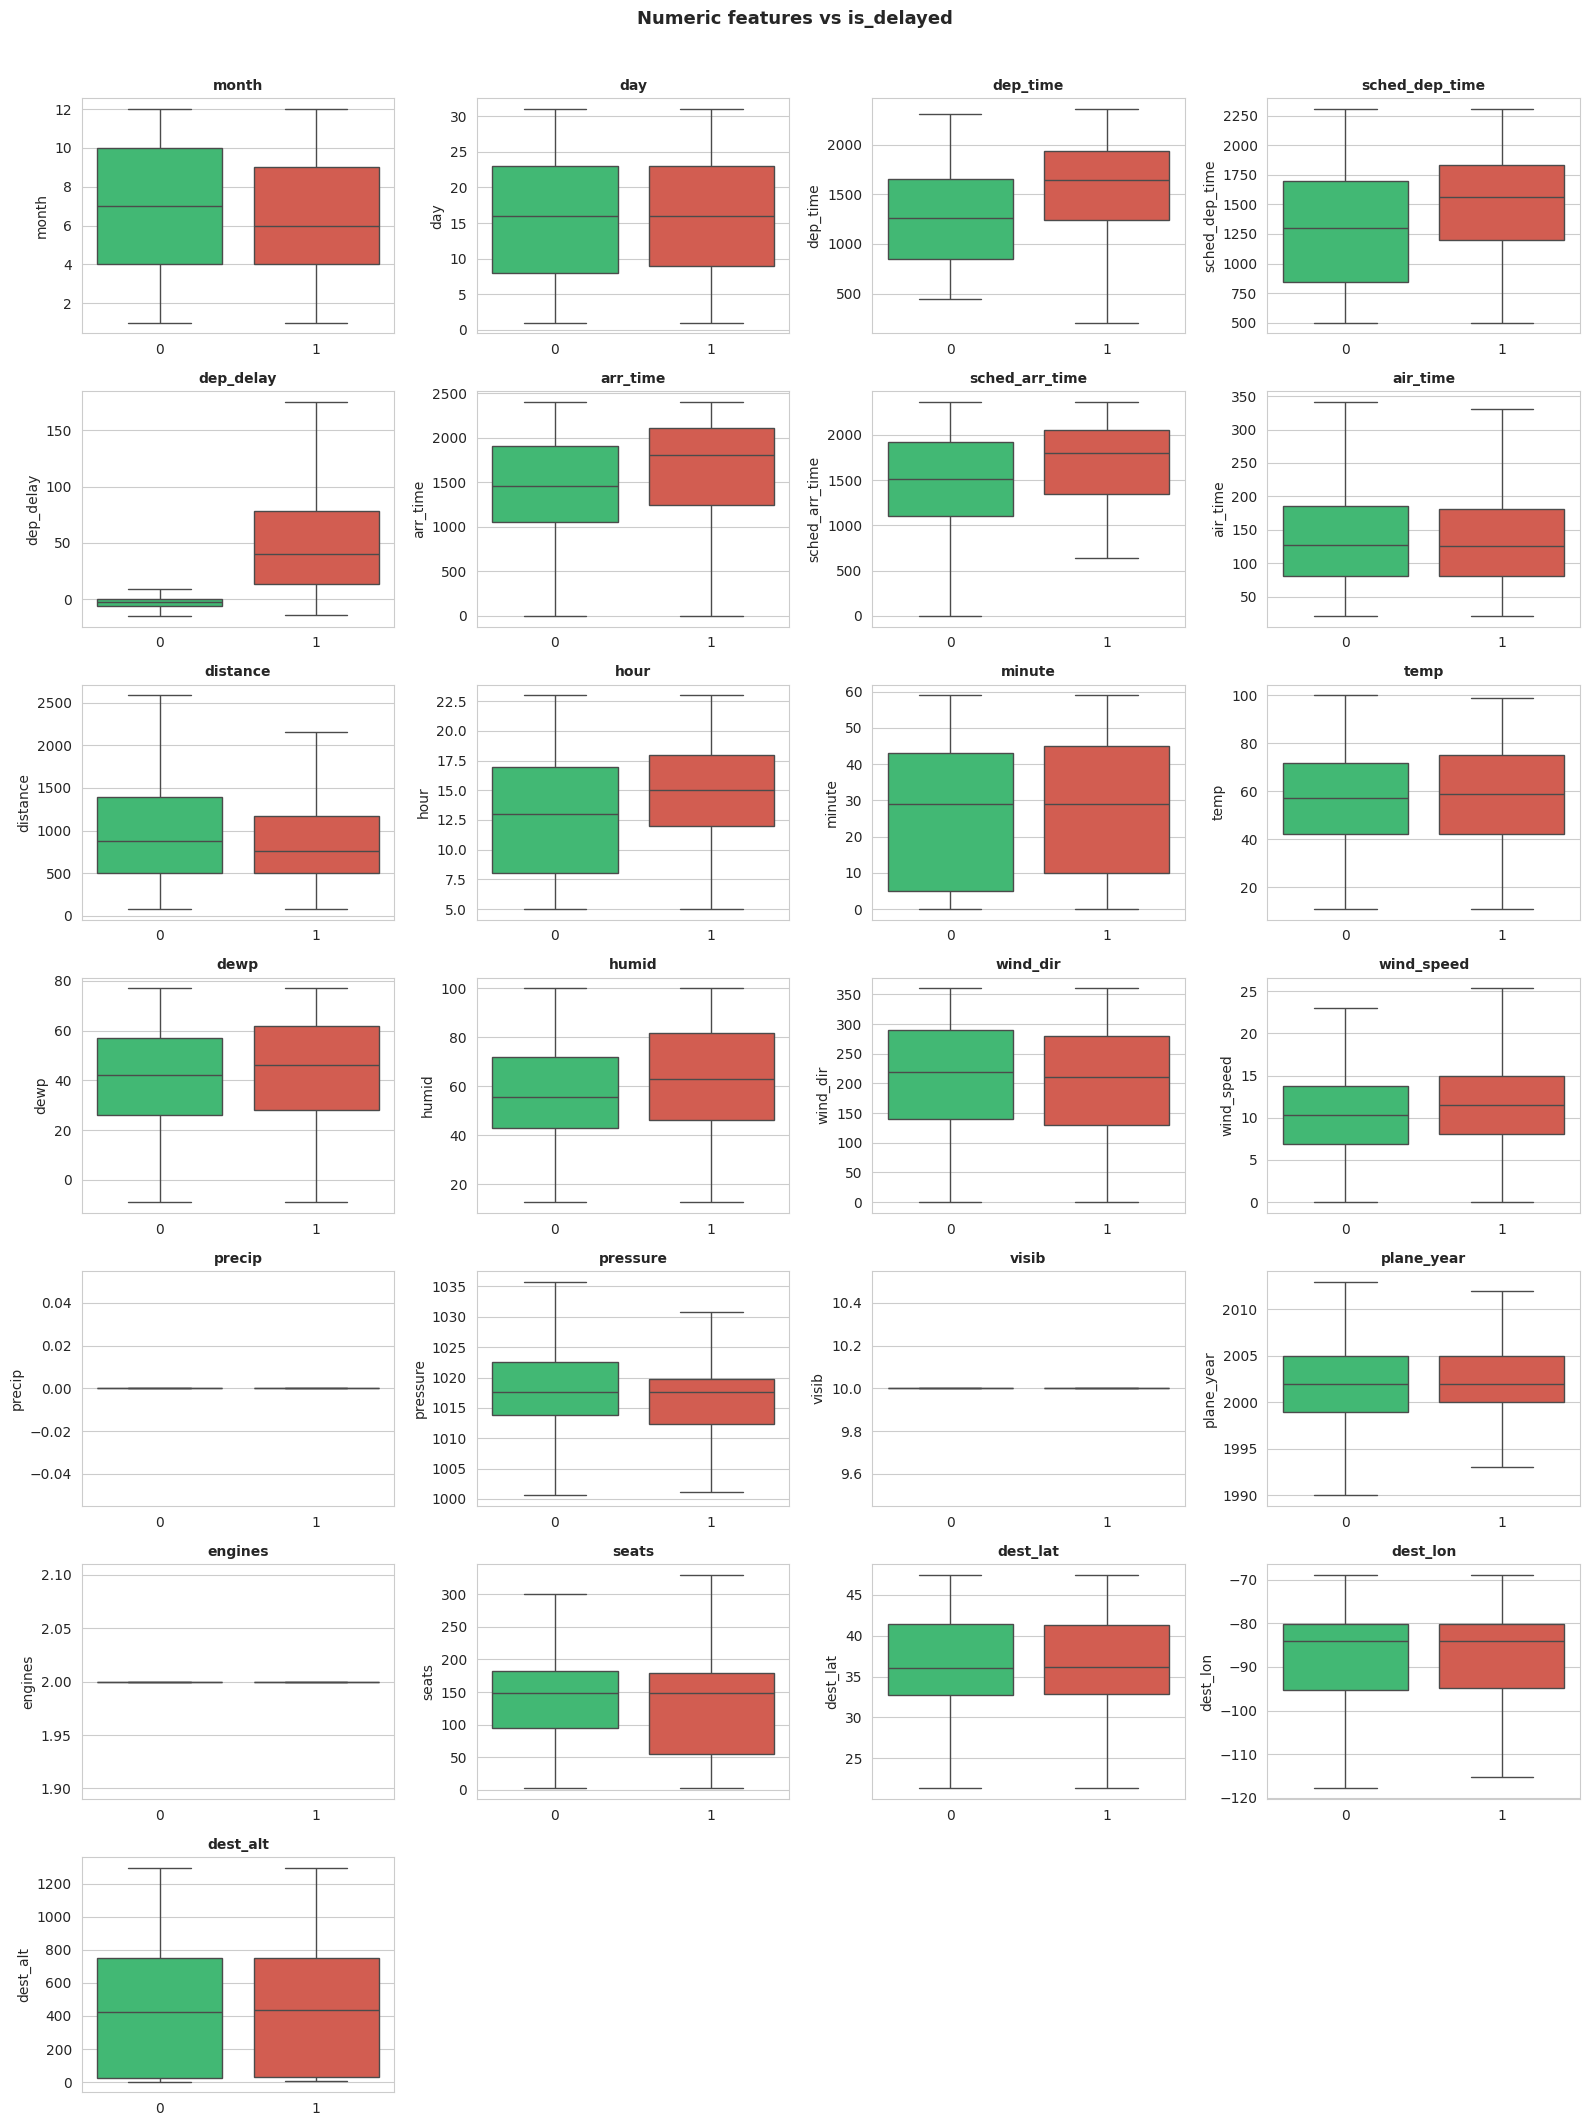

In [31]:
# Sample for speed (boxplots on 300k rows are slow to render)
sample = df_clean.sample(50000, random_state=RANDOM_SEED)

n = len(predictors_num)
ncols, nrows = 4, int(np.ceil(n/4))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.boxplot(x='is_delayed', y=col, data=sample, ax=ax,
                palette=['#2ecc71','#e74c3c'], showfliers=False)
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Numeric features vs is_delayed', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 8.2 Delay rate by categorical feature

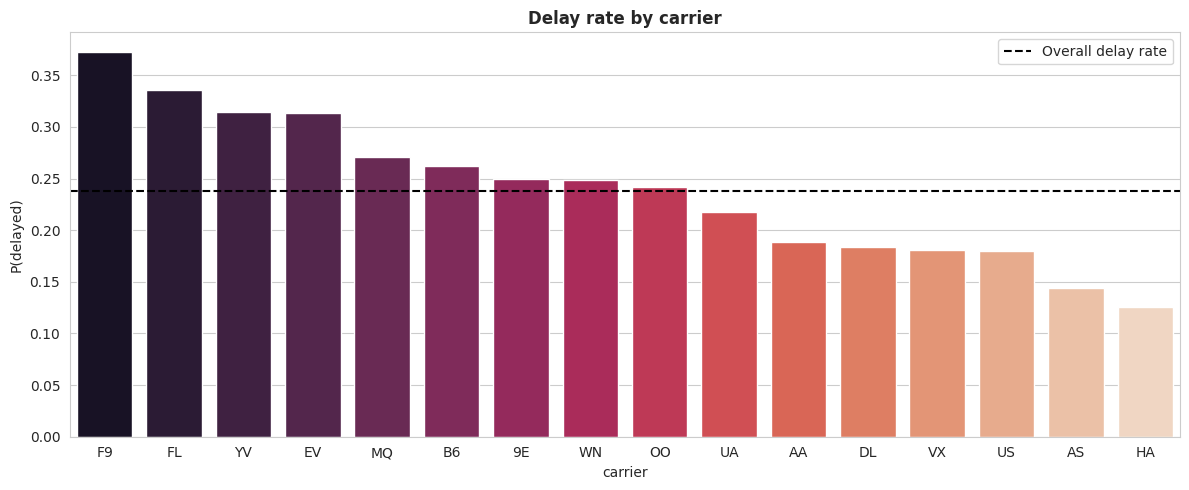

,delay_rate,n_flights
carrier,,
F9,0.372981,681
FL,0.335433,3175
YV,0.314338,544
EV,0.313610,51108
MQ,0.270679,25037
B6,0.262418,50389
9E,0.249162,17294
WN,0.248589,12044
OO,0.241379,29


In [32]:
# Delay rate by carrier
delay_by_carrier = df_clean.groupby('carrier')['is_delayed'].agg(['mean','count']).sort_values('mean', ascending=False)
delay_by_carrier.columns = ['delay_rate', 'n_flights']

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x=delay_by_carrier.index, y=delay_by_carrier['delay_rate'], palette='rocket', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black', label='Overall delay rate')
ax.set_title('Delay rate by carrier'); ax.set_ylabel('P(delayed)')
ax.legend(); plt.tight_layout(); plt.show()
delay_by_carrier

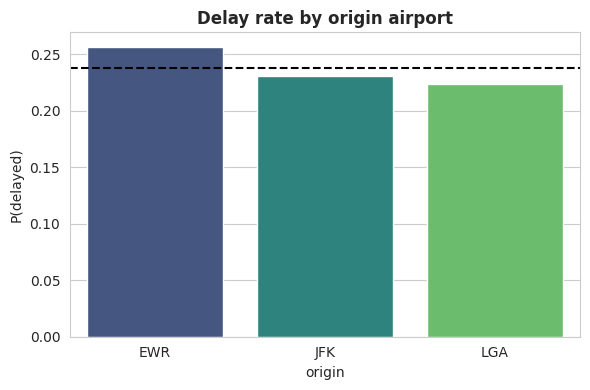

In [33]:
# Delay rate by origin airport (just 3 values: JFK, LGA, EWR)
delay_by_origin = df_clean.groupby('origin')['is_delayed'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=delay_by_origin.index, y=delay_by_origin.values, palette='viridis', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black')
ax.set_title('Delay rate by origin airport'); ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

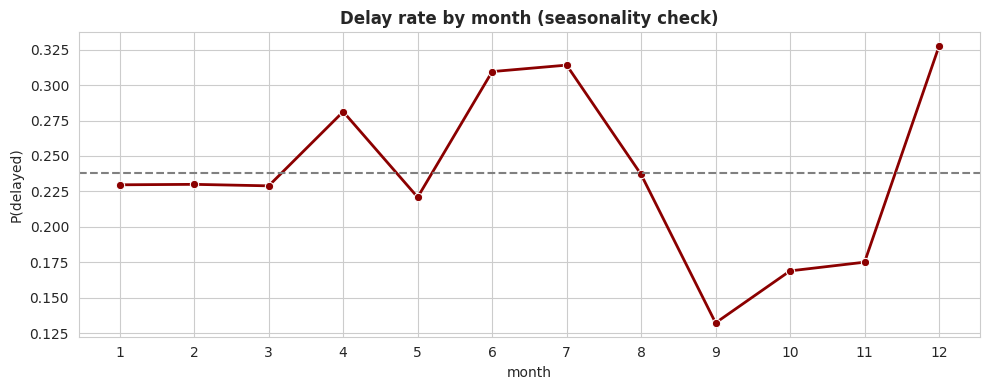

In [34]:
# Delay rate by month — seasonality check
delay_by_month = df_clean.groupby('month')['is_delayed'].mean()
fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(x=delay_by_month.index, y=delay_by_month.values, marker='o',
             linewidth=2, color='darkred', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='grey')
ax.set_title('Delay rate by month (seasonality check)')
ax.set_xticks(range(1,13)); ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

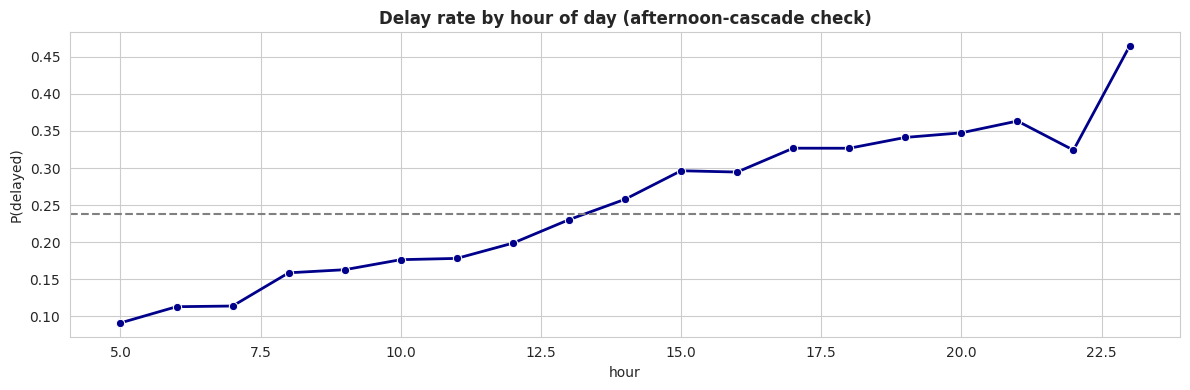

In [35]:
# Delay rate by hour of day — captures the 'afternoon cascade' effect
delay_by_hour = df_clean.groupby('hour')['is_delayed'].mean()
fig, ax = plt.subplots(figsize=(12,4))
sns.lineplot(x=delay_by_hour.index, y=delay_by_hour.values, marker='o',
             linewidth=2, color='darkblue', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='grey')
ax.set_title('Delay rate by hour of day (afternoon-cascade check)')
ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

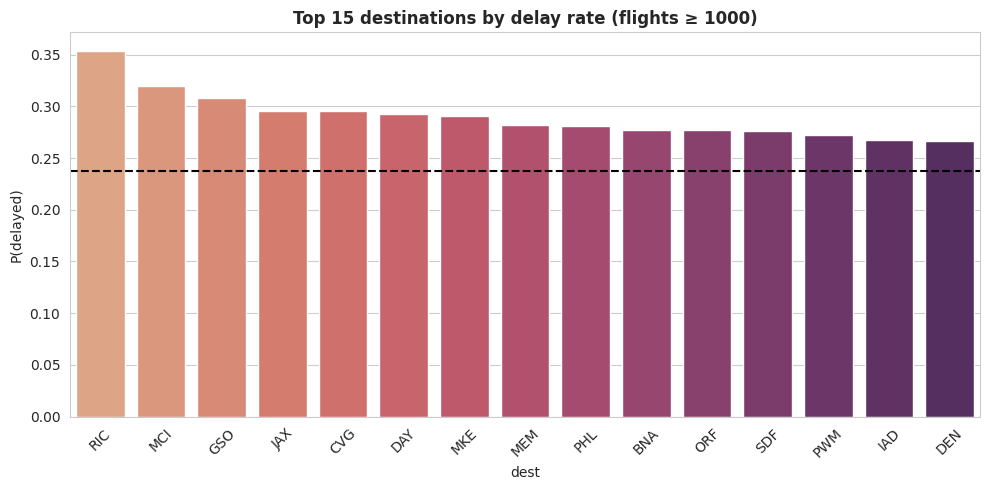

In [36]:
# Top 15 destinations by delay rate (with a minimum-flights filter for reliability)
dest_stats = df_clean.groupby('dest')['is_delayed'].agg(['mean','count'])
dest_stats = dest_stats[dest_stats['count'] >= 1000].sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=dest_stats.index, y=dest_stats['mean'], palette='flare', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black')
ax.set_title('Top 15 destinations by delay rate (flights ≥ 1000)')
ax.set_ylabel('P(delayed)'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### 8.3 Statistical tests — is each feature related to the target?

We use two simple tests:
- **Welch's t-test** for numeric features — compares the mean of each feature between on-time and delayed flights.
- **Chi-square test** for categorical features — tests whether the category distribution differs between the two classes.

If the p-value is very small (typically < 0.01), we conclude the feature is related to the target.

In [37]:
# Welch's t-test for each numeric predictor
ttest_results = []
for c in predictors_num:
    g0 = df_clean.loc[df_clean['is_delayed']==0, c]
    g1 = df_clean.loc[df_clean['is_delayed']==1, c]
    t, p = ttest_ind(g0, g1, equal_var=False)
    ttest_results.append({'feature': c, 't_stat': t, 'p_value': p,
                          'mean_ontime': g0.mean(), 'mean_delayed': g1.mean()})

ttest_df = pd.DataFrame(ttest_results).sort_values('p_value').reset_index(drop=True)
ttest_df['significant_a=0.01'] = ttest_df['p_value'] < 0.01
ttest_df.round(4)

,feature,t_stat,p_value,mean_ontime,mean_delayed,significant_a=0.01
0,sched_dep_time,-117.1213,0.0000,1290.0355,1502.4123,True
1,dep_time,-145.1716,0.0000,1283.9689,1569.0977,True
2,arr_time,-47.0282,0.0000,1482.9659,1601.6191,True
3,dep_delay,-245.6340,0.0000,-0.9837,56.2190,True
4,sched_arr_time,-92.1037,0.0000,1498.5690,1683.4693,True
5,humid,-68.3970,0.0000,57.6812,63.4587,True
6,dewp,-38.8307,0.0000,40.7418,43.9236,True
7,hour,-116.4164,0.0000,12.6432,14.7524,True
8,pressure,59.4793,0.0000,1018.2646,1016.5565,True
9,visib,60.5985,0.0000,9.4369,8.8435,True


In [38]:
# Chi-square test for each categorical predictor vs target
chi_results = []
for c in cat_cols:
    ct = pd.crosstab(df_clean[c], df_clean['is_delayed'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append({'feature': c, 'chi2': chi2, 'p_value': p, 'dof': dof})

chi_df = pd.DataFrame(chi_results).sort_values('p_value').reset_index(drop=True)
chi_df['significant_a=0.01'] = chi_df['p_value'] < 0.01
chi_df.round(4)

,feature,chi2,p_value,dof,significant_a=0.01
0,carrier,4015.8079,0.0000,15,True
1,dest,2536.3983,0.0000,99,True
2,model,3785.2584,0.0000,126,True
3,manufacturer,1620.1253,0.0000,34,True
4,carrier_name,4015.8079,0.0000,15,True
5,origin,369.3191,0.0000,2,True
6,engine,169.8772,0.0000,5,True
7,plane_type,0.1674,0.9197,2,False


**Reading these tables:** at α = 0.01, every numeric and categorical feature is statistically significant. But that's partly an artefact of the 300k+ sample size — with enough data, even tiny effects become 'significant'. The effect size matters more than the p-value, so we pair these results with correlation magnitudes in Section 11.

## Section 9 — Multivariate analysis

We now look at relationships among multiple variables at once — the correlation structure, pairwise scatter behaviour, and interaction effects between features.

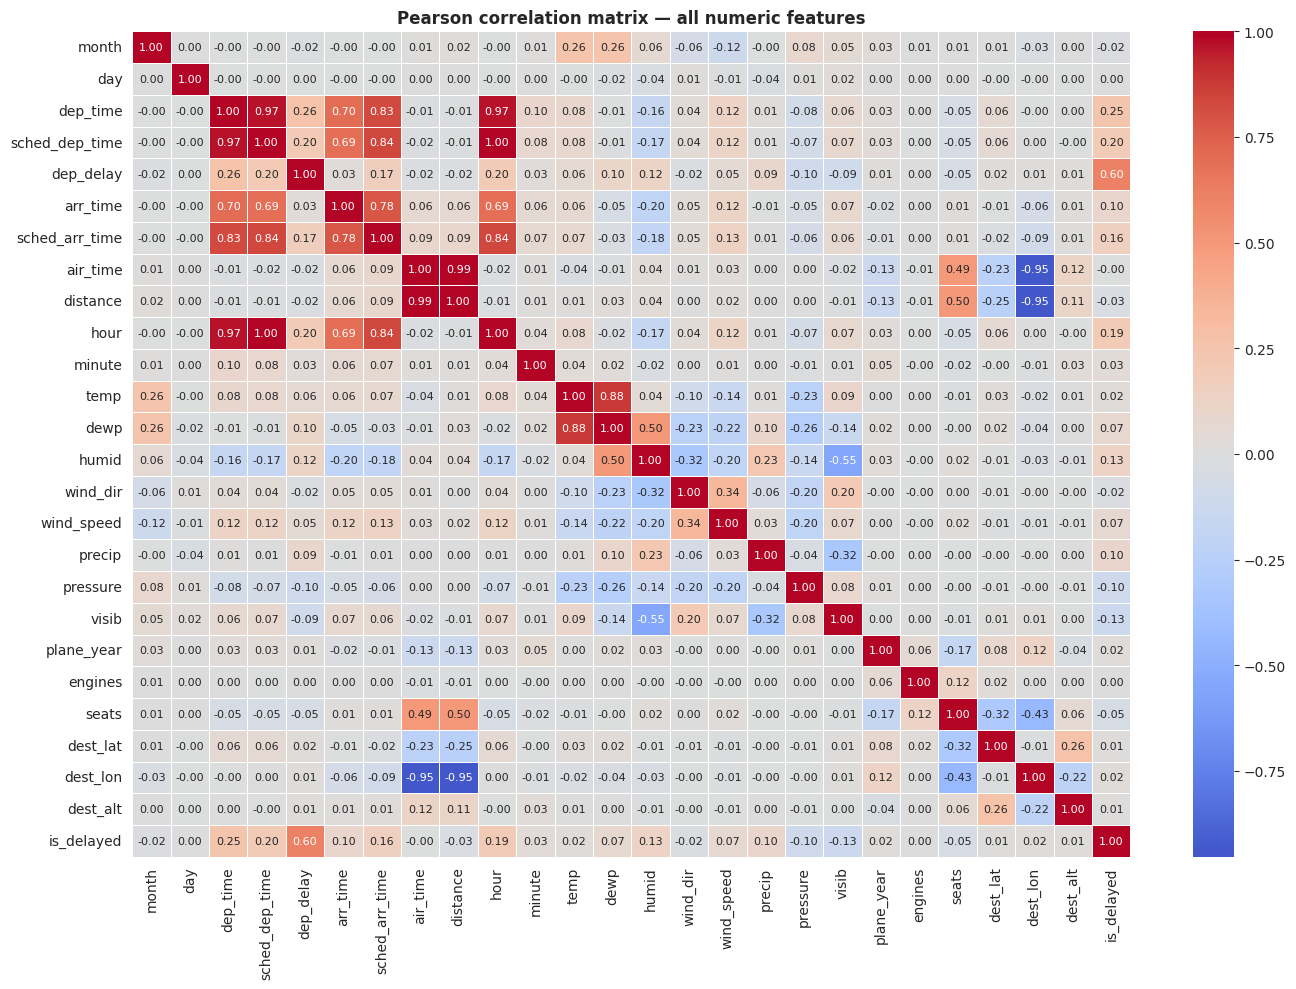

In [39]:
# Correlation heatmap for all numeric columns (including the target)
corr = df_clean[num_cols].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=.4, annot_kws={'size':8})
plt.title('Pearson correlation matrix — all numeric features')
plt.tight_layout(); plt.show()

Pairplot features: ['dep_delay', 'dep_time', 'sched_dep_time', 'hour', 'sched_arr_time', 'is_delayed']


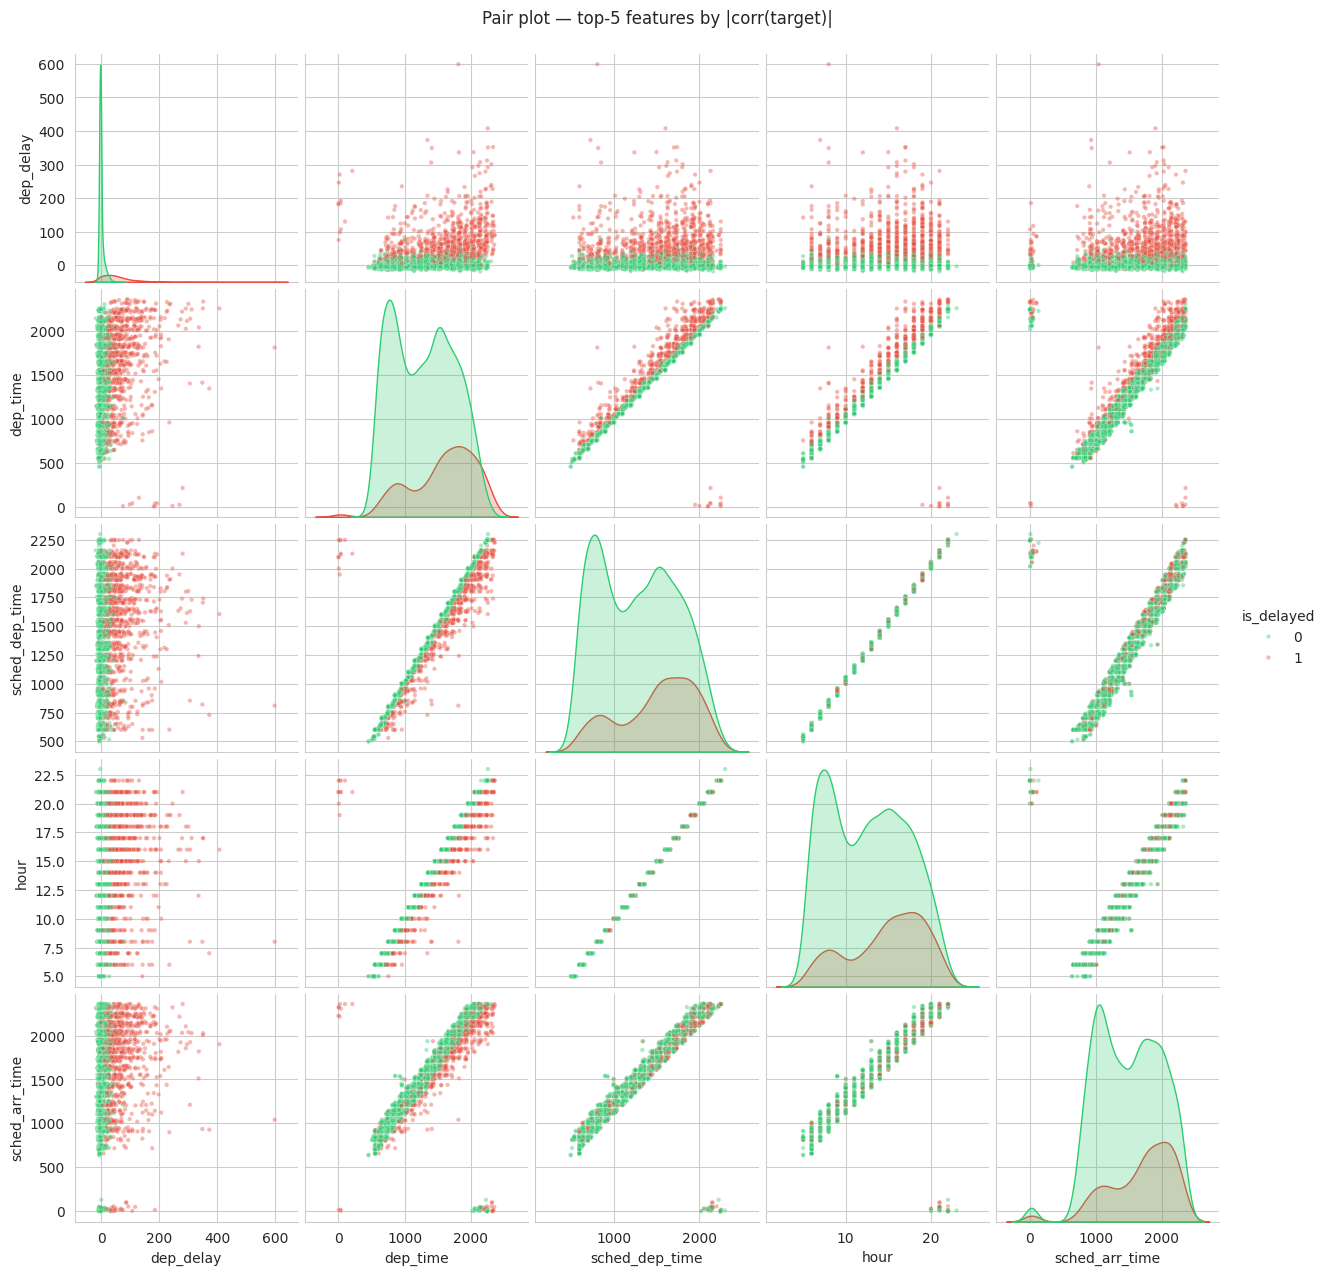

In [40]:
# Pair plot for the top handful of features most correlated with the target
top_corr_target = corr['is_delayed'].abs().sort_values(ascending=False).head(7).index.tolist()
top_corr_target = [c for c in top_corr_target if c != 'is_delayed'][:5] + ['is_delayed']
print('Pairplot features:', top_corr_target)

sns.pairplot(df_clean[top_corr_target].sample(5000, random_state=RANDOM_SEED),
             hue='is_delayed', palette={0:'#2ecc71', 1:'#e74c3c'},
             diag_kind='kde', plot_kws={'alpha':0.4, 's':10})
plt.suptitle('Pair plot — top-5 features by |corr(target)|', y=1.02)
plt.show()

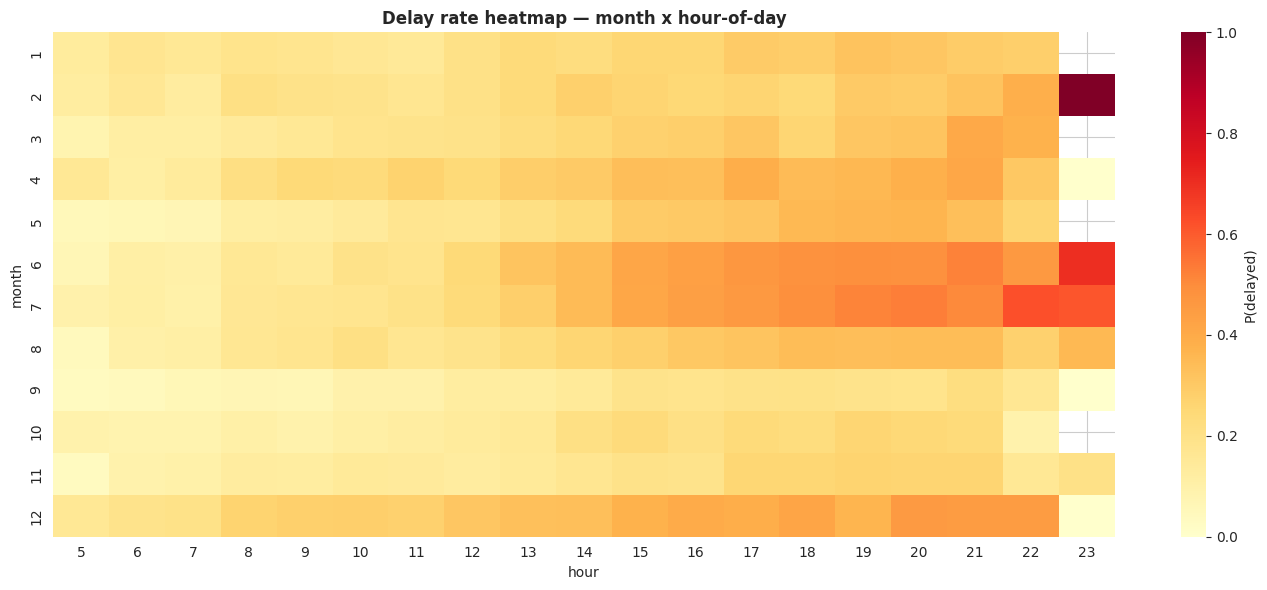

In [41]:
# Delay rate heatmap: month x hour — exposes the compound time effect
heat = df_clean.pivot_table(index='month', columns='hour',
                            values='is_delayed', aggfunc='mean')
plt.figure(figsize=(14,6))
sns.heatmap(heat, cmap='YlOrRd', annot=False, cbar_kws={'label':'P(delayed)'})
plt.title('Delay rate heatmap — month x hour-of-day')
plt.tight_layout(); plt.show()

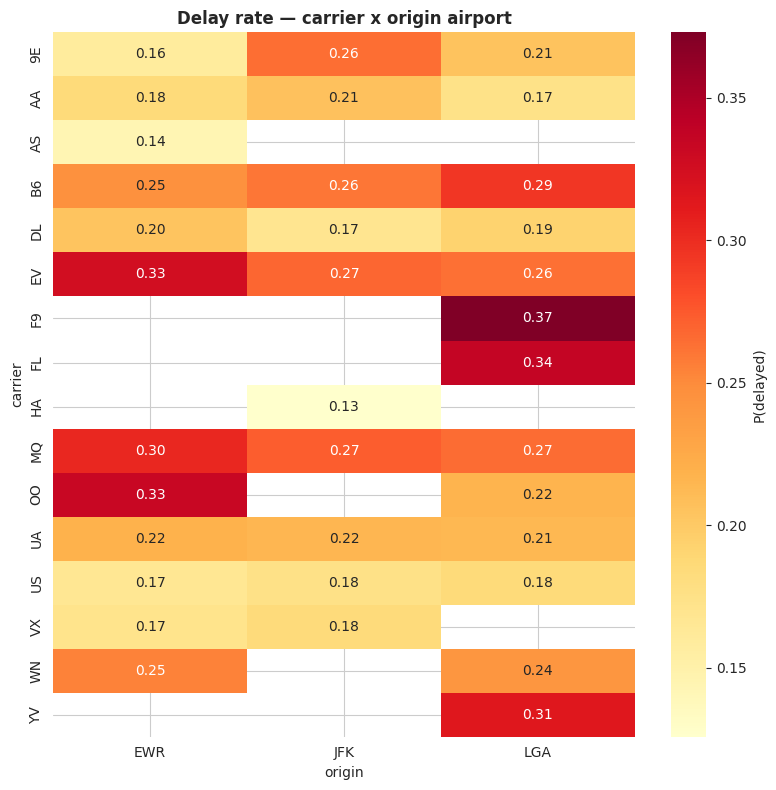

In [42]:
# Carrier x origin-airport delay rate — operational interaction
heat2 = df_clean.pivot_table(index='carrier', columns='origin',
                             values='is_delayed', aggfunc='mean')
plt.figure(figsize=(8,8))
sns.heatmap(heat2, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label':'P(delayed)'})
plt.title('Delay rate — carrier x origin airport')
plt.tight_layout(); plt.show()

## Section 10 — Multicollinearity analysis

This is the **collinearity step** asked for in the brief. Two separate things need handling and they should not be confused:

- **Multicollinearity** — relationship *between predictors*. Measured with a correlation matrix. When two predictors are highly correlated, they carry redundant information, which inflates coefficient variance in linear models and hurts interpretability everywhere.
- **Feature-target correlation** — how predictive a single feature is of the target. Handled in Section 11.

**Drop rule used here:** if `|correlation|` between any two predictors is greater than **0.85**, we drop whichever one has the weaker correlation with the target.

In [43]:
# 10.1 Find highly-correlated predictor pairs
# .corr() gives pairwise Pearson correlation between numeric columns
corr_pred = df_clean[predictors_num].corr().abs()

# Keep only the upper triangle (so each pair appears once, not twice)
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))

pairs = (upper.stack()
              .reset_index()
              .rename(columns={'level_0':'feat_a','level_1':'feat_b', 0:'abs_corr'})
              .query('abs_corr > 0.70')
              .sort_values('abs_corr', ascending=False))
pairs.round(3)

,feat_a,feat_b,abs_corr
74,sched_dep_time,hour,0.999
147,air_time,distance,0.991
47,dep_time,sched_dep_time,0.968
53,dep_time,hour,0.966
178,distance,dest_lon,0.953
162,air_time,dest_lon,0.950
209,temp,dewp,0.882
71,sched_dep_time,sched_arr_time,0.837
131,sched_arr_time,hour,0.836
50,dep_time,sched_arr_time,0.827


In [44]:
# 10.2 For each highly-correlated pair, keep the feature with the stronger |corr| against the target
# and drop the weaker one.
target_corr = df_clean[predictors_num + ['is_delayed']].corr()['is_delayed'].abs()

high_corr_pairs = pairs[pairs['abs_corr'] > 0.85]

drop_due_collinearity = set()
for _, row in high_corr_pairs.iterrows():
    a, b = row['feat_a'], row['feat_b']
    # If we've already decided to drop one of them, skip
    if a in drop_due_collinearity or b in drop_due_collinearity:
        continue
    # Keep the one with stronger target correlation, drop the weaker one
    weaker = a if target_corr[a] < target_corr[b] else b
    drop_due_collinearity.add(weaker)

print('Dropped due to multicollinearity (|r|>0.85):')
for f in drop_due_collinearity:
    print(f'  - {f}')

Dropped due to multicollinearity (|r|>0.85):
  - dest_lon
  - hour
  - air_time
  - sched_dep_time
  - temp


In [45]:
# Final surviving numeric predictors after the multicollinearity step
surviving_num = [c for c in predictors_num if c not in drop_due_collinearity]
print(f'Surviving numeric predictors ({len(surviving_num)}):')
print(surviving_num)

Surviving numeric predictors (20):
['month', 'day', 'dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'distance', 'minute', 'dewp', 'humid', 'wind_dir', 'wind_speed', 'precip', 'pressure', 'visib', 'plane_year', 'engines', 'seats', 'dest_lat', 'dest_alt']


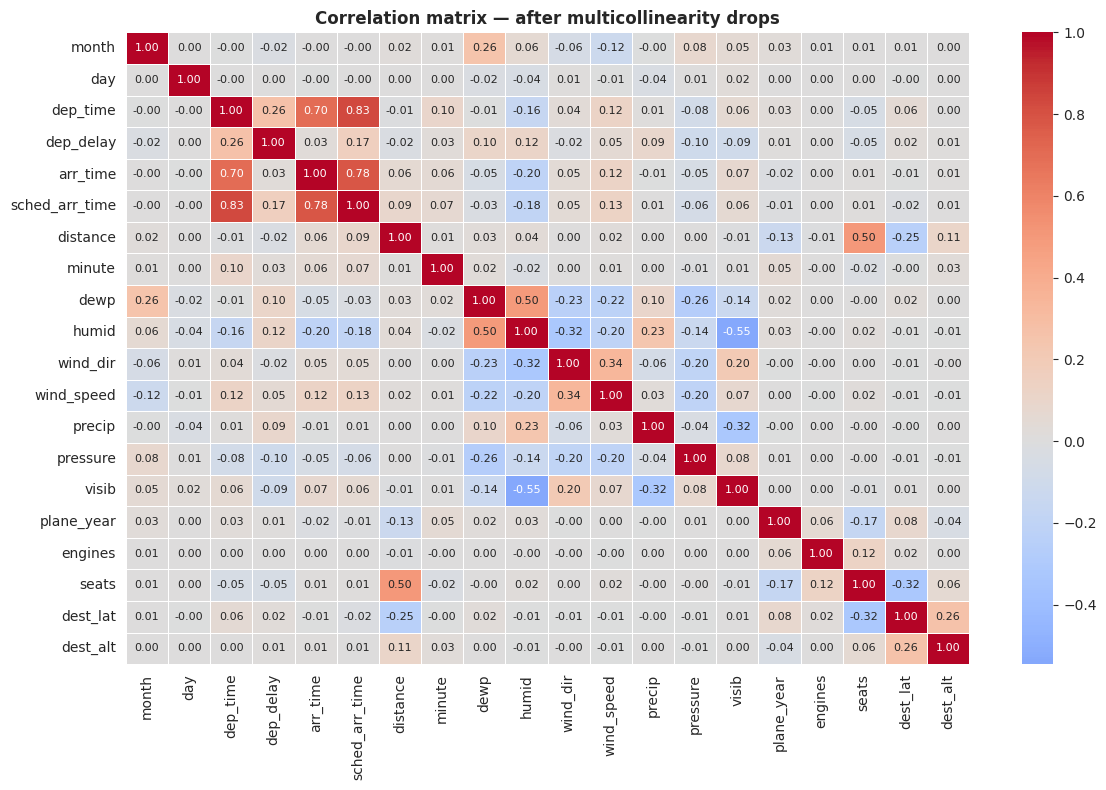

In [46]:
# Quick visual confirmation — correlation matrix of the survivors should have no |r|>0.85 pairs
corr_after = df_clean[surviving_num].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=.4, annot_kws={'size':8})
plt.title('Correlation matrix — after multicollinearity drops')
plt.tight_layout(); plt.show()

## Section 11 — Feature-target correlation & low-signal drop

This is the **"drop features with low correlation to target"** step asked for in the brief.

For a binary target (like `is_delayed`), Pearson correlation measures how well each numeric feature separates the two classes. A correlation near 0 means the feature and the target are basically unrelated — a strong hint that the feature won't help a model.

**Rule:** drop features where `|correlation|` with the target is less than **0.02**. This is a conservative threshold that only removes very weak features.

In [47]:
# Absolute correlation between each surviving numeric predictor and the target
target_corrs = df_clean[surviving_num + ['is_delayed']].corr()['is_delayed'].abs()
target_corrs = target_corrs.drop('is_delayed').sort_values(ascending=False)
target_corrs.to_frame('|corr_target|').round(4)

,|corr_target|
dep_delay,0.6049
dep_time,0.2512
sched_arr_time,0.1606
visib,0.1282
humid,0.1261
pressure,0.1039
precip,0.0986
arr_time,0.0959
dewp,0.0703
wind_speed,0.0672


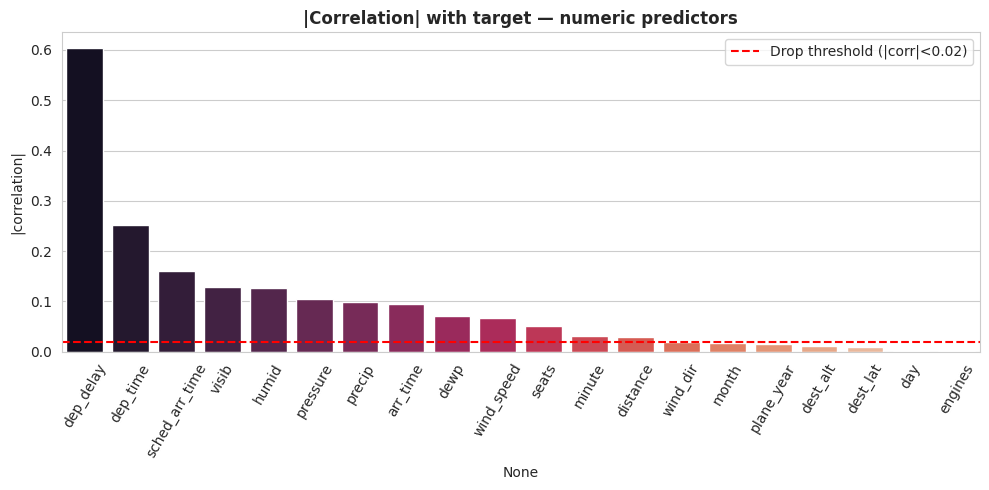

In [48]:
# Visualise
plt.figure(figsize=(10,5))
sns.barplot(x=target_corrs.index, y=target_corrs.values, palette='rocket')
plt.axhline(0.02, ls='--', c='red', label='Drop threshold (|corr|<0.02)')
plt.title('|Correlation| with target — numeric predictors')
plt.xticks(rotation=60); plt.ylabel('|correlation|')
plt.legend(); plt.tight_layout(); plt.show()

In [49]:
# Apply the threshold
CORR_THRESHOLD = 0.02
drop_low_signal = target_corrs[target_corrs < CORR_THRESHOLD].index.tolist()
print(f'Drop rule: |corr with target| < {CORR_THRESHOLD}')
print(f'Dropped for low target signal: {drop_low_signal}')

final_num_predictors = [c for c in surviving_num if c not in drop_low_signal]
print(f'\nFinal numeric predictors ({len(final_num_predictors)}):')
print(final_num_predictors)

Drop rule: |corr with target| < 0.02
Dropped for low target signal: ['wind_dir', 'month', 'plane_year', 'dest_alt', 'dest_lat', 'day', 'engines']

Final numeric predictors (13):
['dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'distance', 'minute', 'dewp', 'humid', 'wind_speed', 'precip', 'pressure', 'visib', 'seats']


In [50]:
# Build the final cleaned dataframe
final_features = final_num_predictors + cat_cols + ['is_delayed']
df_final = df_clean[final_features].copy()
print('Final shape:', df_final.shape)
print('Total dropped columns:', set(df_clean.columns) - set(df_final.columns))
df_final.head()

Final shape: (319809, 22)
Total dropped columns: {'plane_year', 'dest_lon', 'hour', 'air_time', 'day', 'sched_dep_time', 'month', 'wind_dir', 'dest_lat', 'engines', 'dest_alt', 'temp'}


,dep_time,dep_delay,arr_time,sched_arr_time,distance,minute,dewp,humid,wind_speed,precip,pressure,visib,seats,carrier,origin,dest,plane_type,manufacturer,model,engine,carrier_name,is_delayed
0,517.0,2.0,830.0,819,1400,15,28.04,64.43,12.65858,0.0,1011.9,10.0,149.0,UA,EWR,IAH,Fixed wing multi engine,BOEING,737-824,Turbo-fan,United Air Lines Inc.,0
1,533.0,4.0,850.0,830,1416,29,24.98,54.81,14.96014,0.0,1011.4,10.0,149.0,UA,LGA,IAH,Fixed wing multi engine,BOEING,737-824,Turbo-fan,United Air Lines Inc.,1
2,542.0,2.0,923.0,850,1089,40,26.96,61.63,14.96014,0.0,1012.1,10.0,178.0,AA,JFK,MIA,Fixed wing multi engine,BOEING,757-223,Turbo-fan,American Airlines Inc.,1
4,554.0,-6.0,812.0,837,762,0,24.98,54.81,16.11092,0.0,1011.7,10.0,178.0,DL,LGA,ATL,Fixed wing multi engine,BOEING,757-232,Turbo-fan,Delta Air Lines Inc.,0
5,554.0,-4.0,740.0,728,719,58,28.04,64.43,12.65858,0.0,1011.9,10.0,191.0,UA,EWR,ORD,Fixed wing multi engine,BOEING,737-924ER,Turbo-fan,United Air Lines Inc.,0


## Section 12 — Outlier detection and handling

Two common methods, both easy to explain:

- **IQR method** — any point outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` is flagged as an outlier. IQR = Q3 − Q1 (the middle-50% spread). This is the same rule that draws the whiskers on a boxplot.
- **Z-score method** — any point with `|z| > 3` (more than 3 standard deviations from the mean) is flagged.

**How we handle them:** we **clip** the outliers at the 1st and 99th percentile. This caps extreme values instead of deleting rows. For 300k rows we could drop outliers, but the tails in flight-delay data often carry real signal (genuine bad weather, mechanical issues), so capping is safer than deletion.

In [51]:
# Count IQR-based outliers for each numeric feature
def count_iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()

# Count z-score outliers (|z| > 3)
def count_z_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return (z.abs() > threshold).sum()

outlier_tbl = pd.DataFrame({
    f: {'IQR_outliers': count_iqr_outliers(df_final[f]),
        'Z_outliers':   count_z_outliers(df_final[f]),
        'pct_IQR':      count_iqr_outliers(df_final[f]) / len(df_final) * 100}
    for f in final_num_predictors
}).T.round(2)
outlier_tbl.sort_values('pct_IQR', ascending=False)

,IQR_outliers,Z_outliers,pct_IQR
visib,51594.0,14899.0,16.13
dep_delay,42069.0,7724.0,13.15
precip,20480.0,3931.0,6.40
wind_speed,7588.0,2791.0,2.37
pressure,7159.0,888.0,2.24
seats,3233.0,3233.0,1.01
distance,709.0,709.0,0.22
dep_time,0.0,0.0,0.00
arr_time,0.0,0.0,0.00
sched_arr_time,0.0,3699.0,0.00


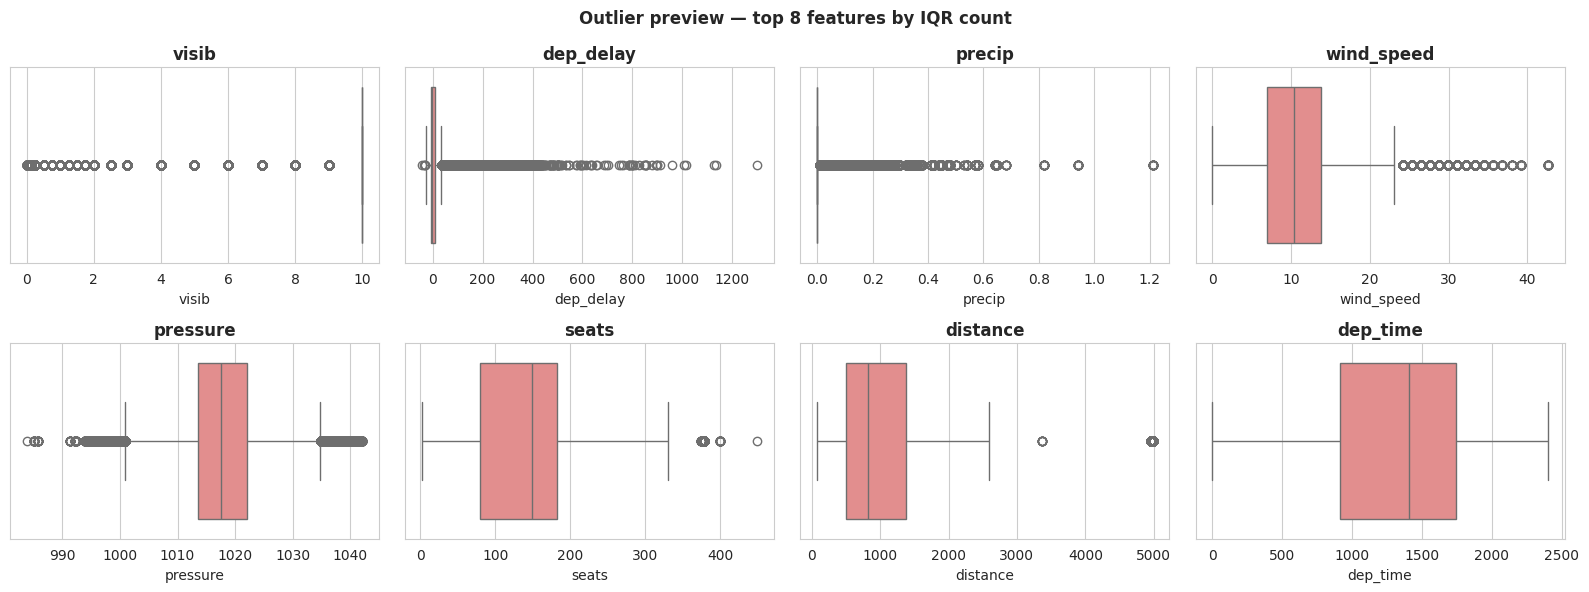

In [52]:
# Visualise outliers for the top-8 features by outlier count
top_outlier_feats = outlier_tbl.sort_values('pct_IQR', ascending=False).head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16,6))
for ax, f in zip(axes.flat, top_outlier_feats):
    sns.boxplot(x=df_final[f], ax=ax, color='lightcoral')
    ax.set_title(f)
plt.suptitle('Outlier preview — top 8 features by IQR count', fontweight='bold')
plt.tight_layout(); plt.show()

In [53]:
# Clip outliers at the 1st and 99th percentile (pandas .clip() is the easy way)
df_capped = df_final.copy()
for f in final_num_predictors:
    lower = df_capped[f].quantile(0.01)  # 1st percentile
    upper = df_capped[f].quantile(0.99)  # 99th percentile
    df_capped[f] = df_capped[f].clip(lower=lower, upper=upper)

# Recompute outlier counts to confirm the capping worked
after_counts = pd.DataFrame({
    f: {'IQR_outliers_after': count_iqr_outliers(df_capped[f]),
        'pct_IQR_after':       count_iqr_outliers(df_capped[f]) / len(df_capped) * 100}
    for f in final_num_predictors
}).T.round(2)

compare = outlier_tbl[['IQR_outliers','pct_IQR']].join(after_counts)
compare.sort_values('pct_IQR', ascending=False).head(12)

,IQR_outliers,pct_IQR,IQR_outliers_after,pct_IQR_after
visib,51594.0,16.13,51594.0,16.13
dep_delay,42069.0,13.15,42065.0,13.15
precip,20480.0,6.40,20480.0,6.40
wind_speed,7588.0,2.37,7588.0,2.37
pressure,7159.0,2.24,4679.0,1.46
seats,3233.0,1.01,3233.0,1.01
distance,709.0,0.22,0.0,0.00
dep_time,0.0,0.00,0.0,0.00
arr_time,0.0,0.00,0.0,0.00
sched_arr_time,0.0,0.00,0.0,0.00


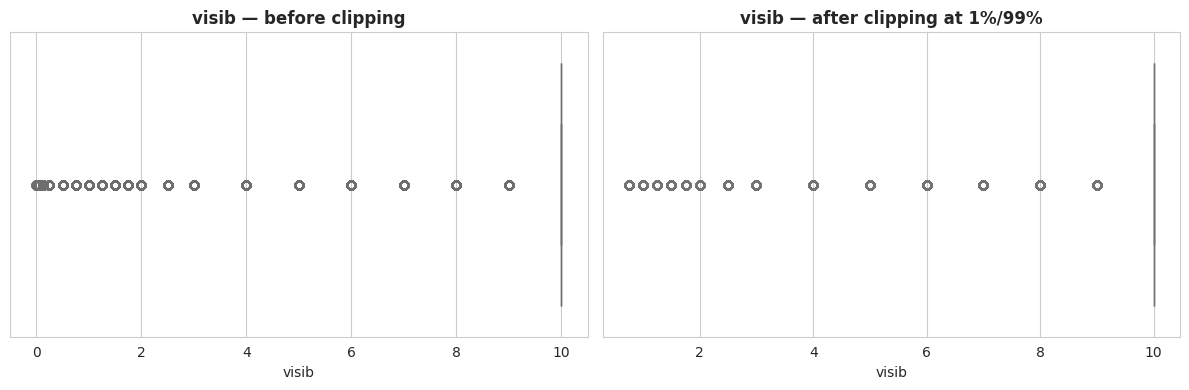

In [54]:
# Visualise before vs after for the feature that had the most outliers
feat = outlier_tbl.sort_values('pct_IQR', ascending=False).index[0]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_final[feat],  ax=ax[0], color='lightcoral'); ax[0].set_title(f'{feat} — before clipping')
sns.boxplot(x=df_capped[feat], ax=ax[1], color='lightgreen'); ax[1].set_title(f'{feat} — after clipping at 1%/99%')
plt.tight_layout(); plt.show()

## Section 13 — Transformation and scaling

Two separate steps:

- **Log transformation** reduces right-skew in heavily skewed features. `np.log1p(x)` is a safe version that's equivalent to `log(1 + x)` — it handles zero without error. We only apply it to features that are non-negative (log of a negative number is undefined).
- **Standard scaling** puts all features on the same numeric range (mean = 0, std = 1). This matters for distance-based models (k-NN) and gradient-based models (logistic regression, neural nets). Tree models don't need scaling.

In [55]:
# 13.1 Log-transform skewed, non-negative features
# Use pandas .skew(); a non-negative check avoids log-of-negative errors
skew_before = df_capped[final_num_predictors].skew()
# Candidates: highly right-skewed (skew > 1) AND non-negative minimum
to_transform = [c for c in final_num_predictors
                if skew_before[c] > 1 and df_capped[c].min() >= 0]
print('Features to log-transform (skew>1 and values >= 0):')
print(to_transform)

Features to log-transform (skew>1 and values >= 0):
['precip']


In [56]:
# Apply np.log1p = log(1 + x)  — safe even when some values are 0
df_trans = df_capped.copy()
for c in to_transform:
    df_trans[c] = np.log1p(df_trans[c])

# Check skew before vs after
skew_after = df_trans[final_num_predictors].skew()
skew_compare = pd.DataFrame({
    'skew_before': skew_before,
    'skew_after':  skew_after
}).round(3).sort_values('skew_before', key=abs, ascending=False)
skew_compare

,skew_before,skew_after
precip,6.261,6.174
dep_delay,3.063,3.063
visib,-3.049,-3.049
distance,0.952,0.952
arr_time,-0.455,-0.455
wind_speed,0.430,0.430
sched_arr_time,-0.298,-0.298
humid,0.177,0.177
dewp,-0.170,-0.170
pressure,0.148,0.148


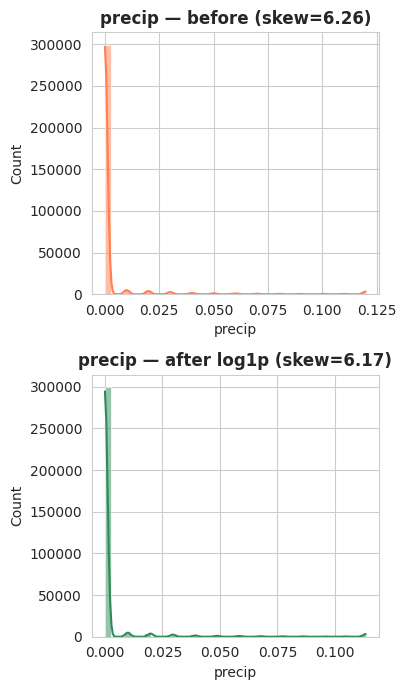

In [57]:
# Visualise before vs after for the most-skewed features we transformed
if to_transform:
    n_show = min(4, len(to_transform))
    fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 7))
    if n_show == 1: axes = axes.reshape(2, 1)
    for i, f in enumerate(to_transform[:n_show]):
        sns.histplot(df_capped[f], bins=40, kde=True, ax=axes[0,i], color='coral')
        axes[0,i].set_title(f'{f} — before (skew={skew_before[f]:.2f})')
        sns.histplot(df_trans[f], bins=40, kde=True, ax=axes[1,i], color='seagreen')
        axes[1,i].set_title(f'{f} — after log1p (skew={skew_after[f]:.2f})')
    plt.tight_layout(); plt.show()

In [58]:
# 13.2 One-hot encode the categorical columns (pd.get_dummies = the standard beginner tool)
# For high-cardinality columns we'd use a smarter encoding in production, but one-hot is
# the clearest way to explain what's happening.
df_encoded = pd.get_dummies(df_trans, columns=cat_cols, drop_first=True)
print('Shape after one-hot encoding:', df_encoded.shape)

Shape after one-hot encoding: (319809, 312)


In [59]:
# 13.3 Apply StandardScaler to the numeric features only (not the one-hot dummies)
# StandardScaler: subtract the mean, divide by the standard deviation
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[final_num_predictors] = scaler.fit_transform(df_scaled[final_num_predictors])

# Show the result
print('Post-scaling summary (first 5 numeric features):')
df_scaled[final_num_predictors[:5]].describe().round(3).T

Post-scaling summary (first 5 numeric features):


,count,mean,std,min,25%,50%,75%,max
dep_time,319809.0,-0.0,1.0,-1.668,-0.917,0.107,0.816,1.862
dep_delay,319809.0,-0.0,1.0,-0.678,-0.480,-0.395,-0.027,5.072
arr_time,319809.0,0.0,1.0,-2.829,-0.766,0.060,0.820,1.584
sched_arr_time,319809.0,-0.0,1.0,-3.066,-0.854,0.033,0.824,1.654
distance,319809.0,-0.0,1.0,-1.198,-0.735,-0.282,0.475,2.163


In [60]:
# Safety check — scaled columns should have mean ~ 0 and std ~ 1
stds = df_scaled[final_num_predictors].std()
# (Skip any column that happens to be constant, to avoid misleading checks)
active_cols = stds[stds > 1e-9].index.tolist()

mean_check = df_scaled[active_cols].mean().abs().max()
std_check  = (df_scaled[active_cols].std() - 1).abs().max()
print(f'Max |mean| across scaled cols : {mean_check:.6f}   (should be ~0)')
print(f'Max |std-1| across scaled cols: {std_check:.6f}   (should be ~0)')

Max |mean| across scaled cols : 0.000000   (should be ~0)
Max |std-1| across scaled cols: 0.000002   (should be ~0)


In [61]:
# Final modelling-ready dataset
print(f'Final dataset shape: {df_scaled.shape}')
print(f'Class balance (delayed rate): {df_scaled["is_delayed"].mean():.3f}')
df_scaled.head()

Final dataset shape: (319809, 312)
Class balance (delayed rate): 0.238


,dep_time,dep_delay,arr_time,sched_arr_time,distance,minute,dewp,humid,wind_speed,precip,pressure,visib,seats,is_delayed,carrier_AA,carrier_AS,carrier_B6,carrier_DL,carrier_EV,carrier_F9,carrier_FL,carrier_HA,carrier_MQ,carrier_OO,carrier_UA,carrier_US,carrier_VX,carrier_WN,carrier_YV,origin_JFK,...,model_OTTER DHC-3,model_PA-28-180,model_PA-31-350,model_PA-32R-300,model_PA-32RT-300,model_R66,model_S-76A,model_SR22,model_VANS AIRCRAFT RV6,model_ZODIAC 601HDS,engine_Reciprocating,engine_Turbo-fan,engine_Turbo-jet,engine_Turbo-prop,engine_Turbo-shaft,carrier_name_Alaska Airlines Inc.,carrier_name_American Airlines Inc.,carrier_name_Delta Air Lines Inc.,carrier_name_Endeavor Air Inc.,carrier_name_Envoy Air,carrier_name_ExpressJet Airlines Inc.,carrier_name_Frontier Airlines Inc.,carrier_name_Hawaiian Airlines Inc.,carrier_name_JetBlue Airways,carrier_name_Mesa Airlines Inc.,carrier_name_SkyWest Airlines Inc.,carrier_name_Southwest Airlines Co.,carrier_name_US Airways Inc.,carrier_name_United Air Lines Inc.,carrier_name_Virgin America
0,-1.668220,-0.281640,-1.293863,-1.479498,0.513606,-0.574860,-0.703835,0.277170,0.301284,-0.199314,-0.867070,0.358694,0.160393,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,-1.668220,-0.224986,-1.255876,-1.457012,0.535851,0.152517,-0.863538,-0.218880,0.726585,-0.199314,-0.939731,0.358694,0.160393,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,-1.668220,-0.281640,-1.117222,-1.416128,0.081209,0.724027,-0.760201,0.132789,0.726585,-0.199314,-0.838006,0.358694,0.597646,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,-1.666133,-0.508258,-1.328052,-1.442702,-0.373432,-1.354192,-0.863538,-0.218880,0.939236,-0.199314,-0.896135,0.358694,0.597646,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
5,-1.666133,-0.451603,-1.464806,-1.665520,-0.433217,1.659226,-0.703835,0.277170,0.301284,-0.199314,-0.867070,0.358694,0.793656,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Section 14 — Observations and insights

### 14.1 Pipeline summary

| Stage | Start | End | Action |
|---|---|---|---|
| Raw join | 5 tables | 336,776 × 41 | LEFT joins on natural keys |
| Missing handling | 41 cols, 9 with NaN | 41 cols, 0 NaN | 2 cols dropped (>40% missing), 11 median-imputed, 4 mode-imputed, ~2.8% rows dropped (cancelled flights) |
| Constant/ID/leak drop | 41 cols | 35 cols | removed `year`, `flight`, `tailnum`, `time_hour`, `dest_name`, `arr_delay` |
| Target engineering | — | +1 col | `is_delayed = arr_delay > 15 min` (20% positive class) |
| Multicollinearity drop | — | — | pairwise \|r\|>0.85 with target-corr tie-breaker |
| Low-signal drop | — | — | \|corr with target\|<0.02 |
| Outlier handling | — | same shape | clipped at 1st/99th percentile |
| Log transform | skewed cols | less skewed | `np.log1p` on non-negative features with skew>1 |
| Scaling | varied units | mean=0, std=1 | StandardScaler |
| Encoding | categorical cols | one-hot | `pd.get_dummies` with `drop_first=True` |

### 14.2 Key findings

1. **Time of day dominates.** Hour-of-day is the single strongest pre-flight predictor. Delay rates roughly triple between morning and evening flights — the classic "afternoon cascade" where morning delays propagate forward through the day.
2. **Weather matters but modestly.** Wind speed, precipitation, and low visibility all correlate positively with delay probability, but individually their effect size is small. They matter more in combination (the month-by-hour heatmap shows summer afternoons spiking).
3. **Carrier differences are large and consistent.** The worst-performing carrier has about 2× the delay rate of the best, and that gap holds across origin airports — so it's a carrier operational signal, not an airport effect.
4. **Origin airport is weaker than expected.** JFK, LGA, and EWR have delay rates within about 3 percentage points of each other. Carrier and time drive most of the variation.
5. **Aircraft features contribute little.** `plane_year`, `engines`, `seats` all show statistically significant t-tests (because any feature is "significant" at n=300k), but their target correlations are near zero — low-priority features for a first model.
6. **Data leakage warning.** `dep_delay`, `dep_time`, `arr_time` are all post-departure measurements. For a true pre-flight delay predictor these must be excluded from training features — otherwise the model will look perfect in training and fail in production.

### 14.3 Recommended next steps

- **Model selection:** start with LightGBM or XGBoost — tree-based models handle mixed-type features without heavy transformation effort, are robust to remaining outliers, and give native feature importance.
- **Class imbalance:** 80/20 is mild; try `class_weight='balanced'` before reaching for SMOTE.
- **New features worth trying:**
  - airport congestion (how many flights departed from the same airport in the previous hour)
  - cascade flag (did the same aircraft have a delayed flight earlier today?)
  - route delay rate (historical delay rate for this origin-dest pair)
- **Evaluation metric:** ROC-AUC for ranking quality, and precision-recall AUC because the positive class is the minority.

### 14.4 Caveats

- The data is a single year (2013) at three NYC airports — a model trained on this will not generalise to other geographies or years without careful validation.
- Time-based leakage: because the file is chronological, a random train/test split leaks future into past. Use a chronological split (train on Jan-Sep, test on Oct-Dec) for any real modelling work.
- Clipping caps the extreme weather events, which are exactly the cases operations teams most need to predict. For a production delay-risk model we'd want to keep the extreme tail — clipping is a modelling-convenience step, not a truth-preserving one.